#### Varadharajan K, CB.SC.P2AIE25030 - 24AI636 - Deep Learning

#### Project: Voice-Based Stress Detection - Review 2: RNN / LSTM / GRU / ResNet18

# Voice-Based Stress Detection using Deep Learning

## Project Overview

This project aims to detect **stress levels from speech signals** using deep learning techniques. Human speech contains acoustic and temporal patterns that reflect emotional and psychological states. By analyzing these patterns, machine learning models can learn to distinguish between **low-stress and high-stress speech signals**.

The project is implemented as part of a **Deep Learning coursework scaffolded project**, where different model architectures are explored and compared systematically.

---

## Problem Statement

Given an input speech recording, the goal is to classify the speech signal into:

- **Low Stress**
- **High Stress**

The classification is performed using extracted acoustic features and deep learning models capable of learning spatial and temporal patterns.

---

## Dataset

The project uses the **RAVDESS Emotional Speech Audio Dataset**, which contains speech recordings of actors expressing different emotions.

Dataset Source:  
https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio

Emotion-to-stress mapping used in this project:

| Emotion | Stress Label |
|-------|-------------|
| Neutral | Low Stress |
| Calm | Low Stress |
| Sad | Low Stress |
| Angry | High Stress |
| Fearful | High Stress |
| Disgust | High Stress |
| Surprised | High Stress |

---

## Project Pipeline

The overall workflow of the project is as follows:

1. Audio preprocessing
2. Feature extraction (MFCC / Mel Spectrogram)
3. Data visualization and exploratory analysis
4. Model training and validation
5. Performance evaluation
6. Model comparison and analysis

---

## Deep Learning Models Explored

### Review 1 – Baseline Models
- Multi-Layer Perceptron (MLP)
- Convolutional Neural Network (CNN)

### Review 2 – Advanced Models
Sequence Models:
- Recurrent Neural Network (RNN)
- Long Short-Term Memory (LSTM)
- Gated Recurrent Unit (GRU)
- Attention-based LSTM

Transfer Learning Models:
- ResNet18
- MobileNetV2

---

## Evaluation Metrics

The models are evaluated using multiple metrics to ensure robust performance comparison:

- Accuracy
- Precision / Recall
- F1 Score
- Confusion Matrix
- ROC Curve
- ROC-AUC Score

---

## Expected Learning Outcomes

This project demonstrates:

- Feature representation of audio signals
- Temporal modeling using sequence networks
- Transfer learning with pretrained CNN architectures
- Hyperparameter experimentation
- Comparative analysis of deep learning models

---

## Reproducibility

To ensure reproducible results, the experiments use fixed random seeds for:

- Python random module
- NumPy
- PyTorch

---

## Author
Varadharajan K <br> 
Deep Learning Project: Voice-Based Stress Detection

In [1]:
#installation of the required libraries
!pip install torch torchvision torchaudio librosa numpy scikit-learn matplotlib seaborn kagglehub -q


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
#importing all the required libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import numpy as np
import librosa, librosa.display
import os, random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from collections import Counter
import pandas as pd
import kagglehub

c:\Users\VARADHARAJAN K\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
#setting the random seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [4]:
#loading the dataset
path = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")
print("Dataset Path:", path)

Dataset Path: C:\Users\VARADHARAJAN K\.cache\kagglehub\datasets\uwrfkaggler\ravdess-emotional-speech-audio\versions\1


In [5]:
#class defined for extracting audio features like MFCC and Mel Spectrogram
class AudioFeatureExtractor:

    def __init__(self, sr=22050, n_mfcc=40):
        self.sr = sr
        self.n_mfcc = n_mfcc

    def load(self, file):
        signal, _ = librosa.load(file, sr=self.sr)
        return signal

    def normalize(self, x):
        return (x - np.mean(x)) / (np.std(x) + 1e-6)

    def pad_seq(self, feat, max_len=173):
        if feat.shape[0] < max_len:
            pad = max_len - feat.shape[0]
            feat = np.pad(feat, ((0,pad),(0,0)))
        else:
            feat = feat[:max_len]
        return feat

    def pad_mel(self, mel, max_len=173):
        if mel.shape[1] < max_len:
            pad = max_len - mel.shape[1]
            mel = np.pad(mel, ((0,0),(0,pad)))
        else:
            mel = mel[:,:max_len]
        return mel

    def extract_mfcc(self, signal):
        mfcc = librosa.feature.mfcc(y=signal, sr=self.sr, n_mfcc=self.n_mfcc)
        mfcc = mfcc.T
        mfcc = self.pad_seq(mfcc)
        return self.normalize(mfcc)

    def extract_mel(self, signal):
        mel = librosa.feature.melspectrogram(y=signal, sr=self.sr)
        mel = librosa.power_to_db(mel, ref=np.max)
        mel = self.pad_mel(mel)
        return self.normalize(mel)

In [6]:
#class defined for creating a custom dataset for RAVDESS audio files, which loads the files, extracts features and prepares them for training
class RAVDESSDataset(Dataset):

    def __init__(self, root_dir, mode="mfcc"):
        self.root = root_dir
        self.mode = mode
        self.extractor = AudioFeatureExtractor()
        self.files = []
        self.labels = []
        self._load()

    def _emotion_to_stress(self, eid):
        eid = int(eid)
        if eid in [1,2,4]: return 0
        if eid in [5,6,7,8]: return 1
        return None

    def _load(self):
        for actor in os.listdir(self.root):
            actor_path = os.path.join(self.root, actor)
            for file in os.listdir(actor_path):
                if file.endswith(".wav"):
                    eid = file.split("-")[2]
                    label = self._emotion_to_stress(eid)
                    if label is not None:
                        self.files.append(os.path.join(actor_path,file))
                        self.labels.append(label)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        file = self.files[idx]
        label = self.labels[idx]
        signal = self.extractor.load(file)

        if self.mode == "mfcc":
            feat = self.extractor.extract_mfcc(signal)
            return torch.tensor(feat,dtype=torch.float32),torch.tensor(label)

        mel = self.extractor.extract_mel(signal)
        return torch.tensor(mel,dtype=torch.float32).unsqueeze(0),torch.tensor(label)

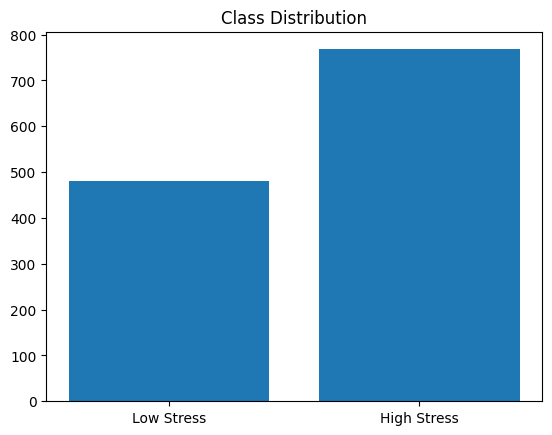

In [7]:
#visualization of the dataset and extracted features
dataset_vis = RAVDESSDataset(path,"mfcc")
counts = Counter(dataset_vis.labels)
plt.bar(["Low Stress","High Stress"],[counts[0],counts[1]])
plt.title("Class Distribution")
plt.show()

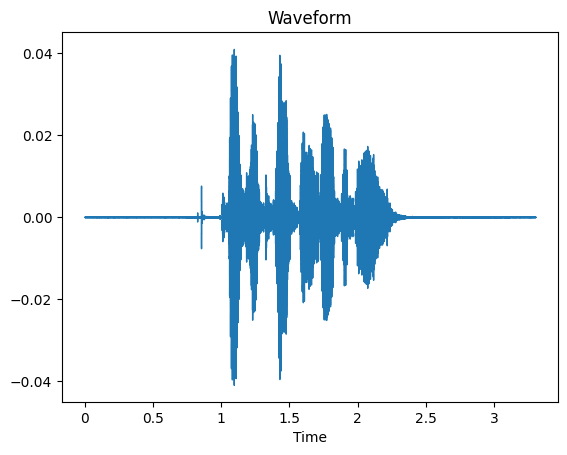

In [8]:
extractor = AudioFeatureExtractor()
signal = extractor.load(dataset_vis.files[0])
librosa.display.waveshow(signal)
plt.title("Waveform")
plt.show()

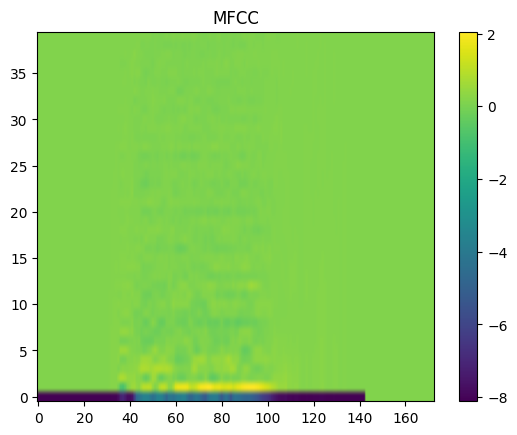

In [9]:
mfcc = extractor.extract_mfcc(signal)
plt.imshow(mfcc.T,aspect="auto",origin="lower")
plt.title("MFCC")
plt.colorbar()
plt.show()

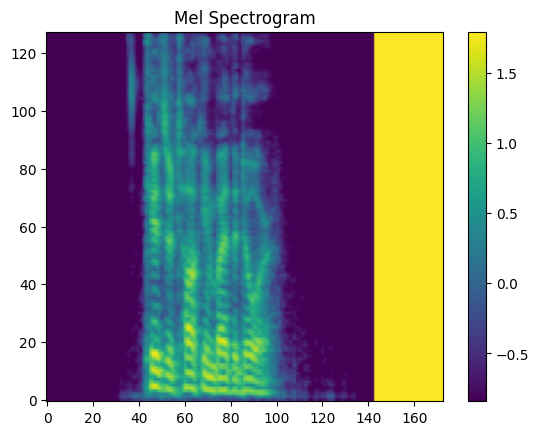

In [10]:
mel = extractor.extract_mel(signal)
plt.imshow(mel,aspect="auto",origin="lower")
plt.title("Mel Spectrogram")
plt.colorbar()
plt.show()

In [11]:
#function defined for preparing the data by splitting it into training, validation and test sets with stratification to maintain class balance
def prepare_data(mode):
    dataset = RAVDESSDataset(path,mode)
    idx=list(range(len(dataset)))
    labels=dataset.labels

    train_idx,temp_idx=train_test_split(idx,test_size=0.3, stratify=labels,random_state=42)

    temp_labels=[labels[i] for i in temp_idx]

    val_idx,test_idx=train_test_split(temp_idx,test_size=0.5, stratify=temp_labels,random_state=42)

    train=torch.utils.data.Subset(dataset,train_idx)
    val=torch.utils.data.Subset(dataset,val_idx)
    test=torch.utils.data.Subset(dataset,test_idx)

    return train,val,test

In [12]:
#class defined for a simple embedding layer that transforms the input features to a higher dimensional space, which can be used as the first layer in the model architecture
class EmbeddingLayer(nn.Module):

    def __init__(self,input_dim=40,embed_dim=128):
        super().__init__()
        self.linear=nn.Linear(input_dim,embed_dim)

    def forward(self,x):
        return self.linear(x)

In [13]:
#class defined for a simple RNN-based model architecture that takes the embedded features as input and outputs the class probabilities for low stress and high stress
class RNNModel(nn.Module):

    def __init__(self,hidden=128):
        super().__init__()
        self.embed=EmbeddingLayer()
        self.rnn=nn.RNN(128,hidden,batch_first=True)
        self.fc=nn.Linear(hidden,2)

    def forward(self,x):
        x=self.embed(x)
        out,_=self.rnn(x)
        return self.fc(out[:,-1,:])

In [14]:
#class defined for a simple LSTM-based model architecture that takes the embedded features as input and outputs the class probabilities for low stress and high stress, which can capture longer-term dependencies in the audio features compared to the RNN model
class LSTMModel(nn.Module):

    def __init__(self,hidden=128,layers=2):
        super().__init__()
        self.embed=EmbeddingLayer()
        self.lstm=nn.LSTM(128,hidden,layers,dropout=0.3,batch_first=True)
        self.fc=nn.Linear(hidden,2)

    def forward(self,x):
        x=self.embed(x)
        out,_=self.lstm(x)
        return self.fc(out[:,-1,:])

In [15]:
#class defined for a simple GRU-based model architecture that takes the embedded features as input and outputs the class probabilities for low stress and high stress, which can capture longer-term dependencies in the audio features compared to the RNN model while being more computationally efficient than the LSTM model
class GRUModel(nn.Module):

    def __init__(self,hidden=128,layers=2):
        super().__init__()
        self.embed=EmbeddingLayer()
        self.gru=nn.GRU(128,hidden,layers,dropout=0.3,batch_first=True)
        self.fc=nn.Linear(hidden,2)

    def forward(self,x):
        x=self.embed(x)
        out,_=self.gru(x)
        return self.fc(out[:,-1,:])

In [16]:
#class defined for a simple attention-based LSTM model architecture that takes the embedded features as input and outputs the class probabilities for low stress and high stress, which can capture longer-term dependencies in the audio features while also allowing the model to focus on the most relevant parts of the input sequence using an attention mechanism
class AttentionLSTM(nn.Module):

    def __init__(self,hidden=128):
        super().__init__()
        self.embed=EmbeddingLayer()
        self.lstm=nn.LSTM(128,hidden,batch_first=True)
        self.attn=nn.Linear(hidden,1)
        self.fc=nn.Linear(hidden,2)

    def forward(self,x):

        x=self.embed(x)
        out,_=self.lstm(x)

        weights=torch.softmax(self.attn(out),dim=1)
        context=torch.sum(weights*out,dim=1)

        return self.fc(context)

In [17]:
#class defined for a simple transfer learning model architecture that uses a pre-trained ResNet-18 model as the base and fine-tunes the last layer to output the class probabilities for low stress and high stress, which can leverage the learned features from the pre-trained model to improve performance on the audio classification task
class ResNetTransfer(nn.Module):

    def __init__(self):

        super().__init__()

        self.model=models.resnet18(pretrained=True)

        for param in self.model.parameters():
            param.requires_grad=False

        for param in self.model.layer4.parameters():
            param.requires_grad=True

        self.model.conv1=nn.Conv2d(1,64,7,2,3,bias=False)
        self.model.fc=nn.Linear(self.model.fc.in_features,2)

    def forward(self,x):
        return self.model(x)

In [18]:
#class defined for a simple transfer learning model architecture that uses a pre-trained MobileNetV2 model as the base and fine-tunes the last layer to output the class probabilities for low stress and high stress, which can leverage the learned features from the pre-trained model to improve performance on the audio classification task while being more lightweight than the ResNet-18 based model
class MobileNetTransfer(nn.Module):

    def __init__(self):

        super().__init__()

        self.model=models.mobilenet_v2(pretrained=True)

        for param in self.model.parameters():
            param.requires_grad=False

        for param in self.model.features[-1].parameters():
            param.requires_grad=True

        self.model.features[0][0]=nn.Conv2d(1,32,3,2,1,bias=False)
        self.model.classifier[1]=nn.Linear(self.model.classifier[1].in_features,2)

    def forward(self,x):
        return self.model(x)

In [19]:
#class defined for implementing early stopping during training, which can help prevent overfitting by monitoring the validation loss and stopping training when it stops improving for a certain number of epochs (patience) with a minimum improvement threshold (min_delta)
class EarlyStopping:

    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float("inf")
        self.counter = 0
        self.best_state = None

    def __call__(self, val_loss, model):

        # improvement
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.best_state = model.state_dict()
            self.counter = 0

        else:
            self.counter += 1

        # stop condition
        if self.counter >= self.patience:
            return True

        return False

In [20]:
#function defined for training the model, which takes the model, training and validation data loaders, learning rate and number of epochs as input, and returns the best model state based on validation AUC score
def train_model(model, train_loader, val_loader, epochs=20, lr=0.0005):

    model.to(device)

    # class balancing
    subset_indices = train_loader.dataset.indices
    full_dataset = train_loader.dataset.dataset

    train_labels = [full_dataset.labels[i] for i in subset_indices]

    class_counts = Counter(train_labels)
    total = sum(class_counts.values())

    weights = torch.tensor([
        total/(class_counts.get(0,1)),
        total/(class_counts.get(1,1))
    ], dtype=torch.float32).to(device)

    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    early_stop = EarlyStopping(patience=5)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):

        model.train()
        train_loss = 0

        for x,y in train_loader:

            x,y = x.to(device), y.to(device)

            optimizer.zero_grad()

            outputs = model(x)

            loss = criterion(outputs,y)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(),5)

            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        val_loss = 0

        with torch.no_grad():

            for x,y in val_loader:

                x,y = x.to(device), y.to(device)

                outputs = model(x)

                loss = criterion(outputs,y)

                val_loss += loss.item()

        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        # early stopping
        if early_stop(val_loss, model):

            print(f"Early stopping triggered at epoch {epoch+1}")

            break

    model.load_state_dict(early_stop.best_state)

    plt.figure()
    plt.plot(train_losses,label="Train Loss")
    plt.plot(val_losses,label="Validation Loss")
    plt.title("Training Curve")
    plt.legend()
    plt.show()

    model.eval()

    all_probs = []
    all_labels = []

    with torch.no_grad():

        for x,y in val_loader:

            x = x.to(device)

            outputs = model(x)

            probs = torch.softmax(outputs, dim=1)[:,1]

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(y.numpy())

    val_auc = roc_auc_score(all_labels, all_probs)

    print("Validation ROC-AUC:", val_auc)

    return model, val_auc

In [21]:
#function defined for evaluating the model on the test set, which takes the model, test data loader and a name for the evaluation as input, and prints the classification report, confusion matrix and ROC curve along with the AUC score
def evaluate(model,loader,name):

    model.eval()

    preds=[]
    probs=[]
    labels=[]

    with torch.no_grad():

        for x,y in loader:

            x=x.to(device)

            out=model(x)

            prob=torch.softmax(out,dim=1)[:,1]
            pred=torch.argmax(out,dim=1)

            preds.extend(pred.cpu().numpy())
            probs.extend(prob.cpu().numpy())
            labels.extend(y.numpy())

    print(f"\n{name}")
    print(classification_report(labels,preds))

    cm=confusion_matrix(labels,preds)
    sns.heatmap(cm,annot=True,fmt="d")
    plt.title(name)
    plt.show()

    auc=roc_auc_score(labels,probs)

    fpr,tpr,_=roc_curve(labels,probs)
    plt.plot(fpr,tpr,label=f"AUC={auc:.3f}")
    plt.plot([0,1],[0,1],'--')
    plt.legend()
    plt.title(name+" ROC Curve")
    plt.show()

    return auc

In [22]:
#function defined for tuning the hyperparameters of the sequence models (RNN, LSTM, GRU, AttentionLSTM) by performing a grid search over different learning rates, batch sizes, hidden sizes and number of layers, and returning the best model and its validation AUC score for each model type
def tune_sequence_models():

    train, val, test = prepare_data("mfcc")

    learning_rates = [0.001, 0.0005]
    batch_sizes = [16, 32]
    hidden_sizes = [64, 128]
    layers = [1, 2]

    results = []

    model_builders = {
        "RNN": lambda h, l: RNNModel(hidden=h),
        "LSTM": lambda h, l: LSTMModel(hidden=h, layers=l),
        "GRU": lambda h, l: GRUModel(hidden=h, layers=l),
        "AttentionLSTM": lambda h, l: AttentionLSTM(hidden=h)
    }

    for model_name, build_model in model_builders.items():

        best_auc = 0
        best_config = None
        best_model = None

        print(f"\n===== Tuning {model_name} =====")

        for lr in learning_rates:
            for bs in batch_sizes:
                for hidden in hidden_sizes:
                    for layer in layers:

                        print(f"\nConfig: lr={lr}, batch={bs}, hidden={hidden}, layers={layer}")

                        train_loader = DataLoader(train, batch_size=bs, shuffle=True)
                        val_loader = DataLoader(val, batch_size=bs)

                        model = build_model(hidden, layer)

                        model, val_auc = train_model(model, train_loader, val_loader, lr=lr)

                        if val_auc > best_auc:
                            best_auc = val_auc
                            best_config = {
                                "lr": lr,
                                "batch_size": bs,
                                "hidden_size": hidden,
                                "layers": layer
                            }
                            best_model = model

        print(f"\nBest config for {model_name}: {best_config}")
        print(f"Best validation AUC: {best_auc:.4f}")

        results.append({
            "Model": model_name,
            "Best AUC": best_auc,
            "Best Config": best_config,
            "Model Object": best_model
        })

    return results, test

In [23]:
#function defined for tuning the hyperparameters of the CNN-based models (ResNet18 and MobileNetV2) by performing a grid search over different learning rates and batch sizes, and returning the best model and its validation AUC score for each model type
def tune_cnn_models():
    train, val, test = prepare_data("mel")
    learning_rates = [0.0005, 0.0001]
    batch_sizes = [16, 32]
    results = []
    model_builders = {
        "ResNet18": lambda: ResNetTransfer(),
        "MobileNetV2": lambda: MobileNetTransfer()}
    for model_name, build_model in model_builders.items():

        best_auc = 0
        best_config = None
        best_model = None

        print(f"\n===== Tuning {model_name} =====")

        for lr in learning_rates:
            for bs in batch_sizes:

                print(f"\nConfig: lr={lr}, batch={bs}")

                train_loader = DataLoader(train, batch_size=bs, shuffle=True)
                val_loader = DataLoader(val, batch_size=bs)

                model = build_model()

                model, val_auc = train_model(model, train_loader, val_loader, lr=lr)

                if val_auc > best_auc:
                    best_auc = val_auc
                    best_config = {
                        "lr": lr,
                        "batch_size": bs
                    }
                    best_model = model

        print(f"\nBest config for {model_name}: {best_config}")
        print(f"Best validation AUC: {best_auc:.4f}")

        results.append({
            "Model": model_name,
            "Best AUC": best_auc,
            "Best Config": best_config,
            "Model Object": best_model})

    return results, test


===== Tuning RNN =====

Config: lr=0.001, batch=16, hidden=64, layers=1
Epoch 1 | Train Loss: 0.6964 | Val Loss: 0.6932
Epoch 2 | Train Loss: 0.6934 | Val Loss: 0.6932
Epoch 3 | Train Loss: 0.6905 | Val Loss: 0.6913
Epoch 4 | Train Loss: 0.6920 | Val Loss: 0.6911
Epoch 5 | Train Loss: 0.6904 | Val Loss: 0.6887
Epoch 6 | Train Loss: 0.6897 | Val Loss: 0.6915
Epoch 7 | Train Loss: 0.6903 | Val Loss: 0.6890
Epoch 8 | Train Loss: 0.6856 | Val Loss: 0.6967
Epoch 9 | Train Loss: 0.6854 | Val Loss: 0.6832
Epoch 10 | Train Loss: 0.6863 | Val Loss: 0.6873
Epoch 11 | Train Loss: 0.6898 | Val Loss: 0.6897
Epoch 12 | Train Loss: 0.6859 | Val Loss: 0.6880
Epoch 13 | Train Loss: 0.6875 | Val Loss: 0.6900
Epoch 14 | Train Loss: 0.6854 | Val Loss: 0.6874
Early stopping triggered at epoch 14


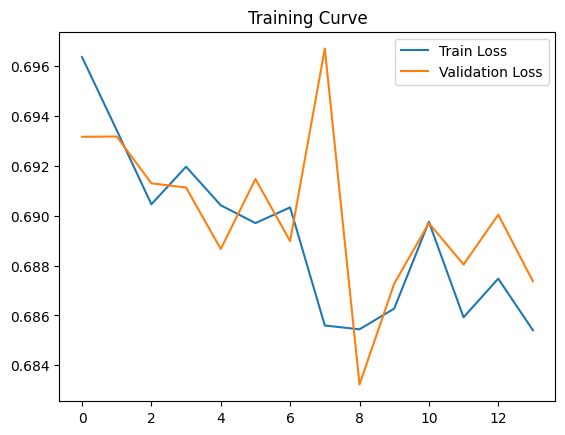

Validation ROC-AUC: 0.5780193236714977

Config: lr=0.001, batch=16, hidden=64, layers=2
Epoch 1 | Train Loss: 0.6984 | Val Loss: 0.6994
Epoch 2 | Train Loss: 0.6906 | Val Loss: 0.6974
Epoch 3 | Train Loss: 0.6967 | Val Loss: 0.6914
Epoch 4 | Train Loss: 0.6912 | Val Loss: 0.6920
Epoch 5 | Train Loss: 0.6894 | Val Loss: 0.6920
Epoch 6 | Train Loss: 0.6885 | Val Loss: 0.6896
Epoch 7 | Train Loss: 0.6899 | Val Loss: 0.6857
Epoch 8 | Train Loss: 0.6881 | Val Loss: 0.6890
Epoch 9 | Train Loss: 0.6893 | Val Loss: 0.6860
Epoch 10 | Train Loss: 0.6863 | Val Loss: 0.6857
Epoch 11 | Train Loss: 0.6890 | Val Loss: 0.6852
Epoch 12 | Train Loss: 0.6887 | Val Loss: 0.6849
Early stopping triggered at epoch 12


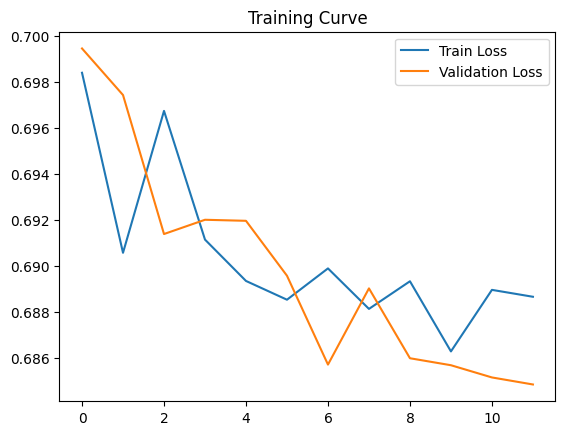

Validation ROC-AUC: 0.5886473429951691

Config: lr=0.001, batch=16, hidden=128, layers=1
Epoch 1 | Train Loss: 0.6990 | Val Loss: 0.7072
Epoch 2 | Train Loss: 0.6929 | Val Loss: 0.6928
Epoch 3 | Train Loss: 0.6932 | Val Loss: 0.6990
Epoch 4 | Train Loss: 0.6912 | Val Loss: 0.6883
Epoch 5 | Train Loss: 0.7090 | Val Loss: 0.6910
Epoch 6 | Train Loss: 0.6885 | Val Loss: 0.6926
Epoch 7 | Train Loss: 0.6920 | Val Loss: 0.6916
Epoch 8 | Train Loss: 0.6905 | Val Loss: 0.6900
Epoch 9 | Train Loss: 0.6892 | Val Loss: 0.6888
Early stopping triggered at epoch 9


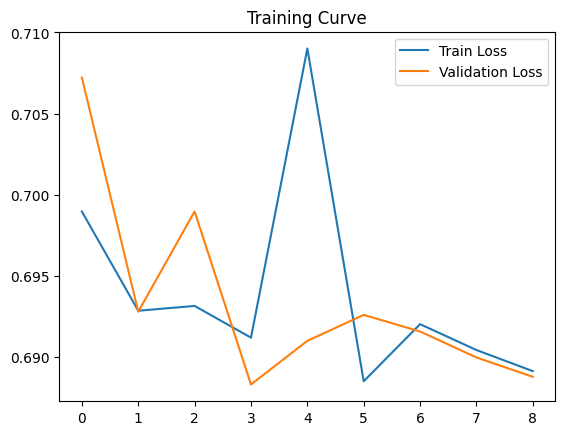

Validation ROC-AUC: 0.5972222222222222

Config: lr=0.001, batch=16, hidden=128, layers=2
Epoch 1 | Train Loss: 0.6988 | Val Loss: 0.7007
Epoch 2 | Train Loss: 0.6921 | Val Loss: 0.6973
Epoch 3 | Train Loss: 0.6912 | Val Loss: 0.6873
Epoch 4 | Train Loss: 0.6996 | Val Loss: 0.6891
Epoch 5 | Train Loss: 0.6991 | Val Loss: 0.6923
Epoch 6 | Train Loss: 0.6946 | Val Loss: 0.6916
Epoch 7 | Train Loss: 0.6906 | Val Loss: 0.6963
Epoch 8 | Train Loss: 0.6905 | Val Loss: 0.6900
Early stopping triggered at epoch 8


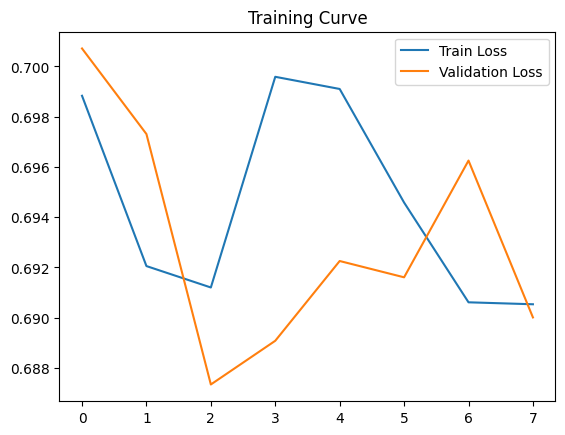

Validation ROC-AUC: 0.5908212560386473

Config: lr=0.001, batch=32, hidden=64, layers=1
Epoch 1 | Train Loss: 0.6976 | Val Loss: 0.6903
Epoch 2 | Train Loss: 0.6920 | Val Loss: 0.6901
Epoch 3 | Train Loss: 0.6875 | Val Loss: 0.6864
Epoch 4 | Train Loss: 0.6899 | Val Loss: 0.6888
Epoch 5 | Train Loss: 0.6971 | Val Loss: 0.6885
Epoch 6 | Train Loss: 0.6894 | Val Loss: 0.6882
Epoch 7 | Train Loss: 0.6901 | Val Loss: 0.6879
Epoch 8 | Train Loss: 0.6855 | Val Loss: 0.6846
Epoch 9 | Train Loss: 0.6898 | Val Loss: 0.6853
Epoch 10 | Train Loss: 0.6879 | Val Loss: 0.6811
Epoch 11 | Train Loss: 0.6850 | Val Loss: 0.6817
Epoch 12 | Train Loss: 0.6864 | Val Loss: 0.6821
Epoch 13 | Train Loss: 0.6843 | Val Loss: 0.6843
Epoch 14 | Train Loss: 0.6828 | Val Loss: 0.6790
Epoch 15 | Train Loss: 0.6902 | Val Loss: 0.6813
Epoch 16 | Train Loss: 0.6825 | Val Loss: 0.6813
Epoch 17 | Train Loss: 0.6869 | Val Loss: 0.6807
Epoch 18 | Train Loss: 0.6863 | Val Loss: 0.6842
Epoch 19 | Train Loss: 0.6854 | Val Los

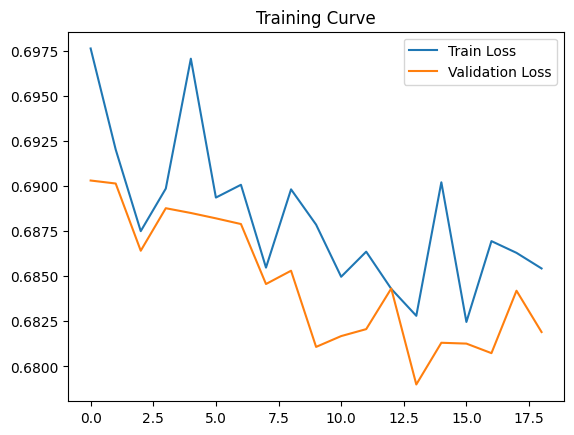

Validation ROC-AUC: 0.5917874396135265

Config: lr=0.001, batch=32, hidden=64, layers=2
Epoch 1 | Train Loss: 0.7019 | Val Loss: 0.6929
Epoch 2 | Train Loss: 0.6921 | Val Loss: 0.6903
Epoch 3 | Train Loss: 0.6947 | Val Loss: 0.6957
Epoch 4 | Train Loss: 0.6954 | Val Loss: 0.6891
Epoch 5 | Train Loss: 0.6889 | Val Loss: 0.6893
Epoch 6 | Train Loss: 0.6894 | Val Loss: 0.6859
Epoch 7 | Train Loss: 0.6907 | Val Loss: 0.6833
Epoch 8 | Train Loss: 0.6822 | Val Loss: 0.6846
Epoch 9 | Train Loss: 0.6868 | Val Loss: 0.6856
Epoch 10 | Train Loss: 0.6853 | Val Loss: 0.6858
Epoch 11 | Train Loss: 0.6861 | Val Loss: 0.6820
Epoch 12 | Train Loss: 0.6857 | Val Loss: 0.6830
Epoch 13 | Train Loss: 0.6849 | Val Loss: 0.6813
Epoch 14 | Train Loss: 0.6843 | Val Loss: 0.6806
Epoch 15 | Train Loss: 0.6839 | Val Loss: 0.6849
Epoch 16 | Train Loss: 0.6858 | Val Loss: 0.6804
Epoch 17 | Train Loss: 0.6806 | Val Loss: 0.6824
Epoch 18 | Train Loss: 0.6964 | Val Loss: 0.6824
Epoch 19 | Train Loss: 0.6836 | Val Los

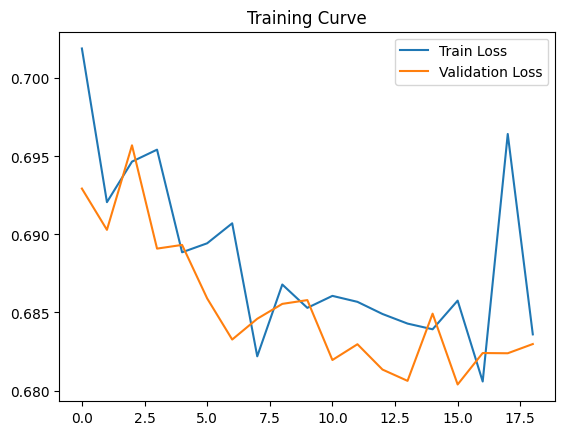

Validation ROC-AUC: 0.5894927536231885

Config: lr=0.001, batch=32, hidden=128, layers=1
Epoch 1 | Train Loss: 0.7023 | Val Loss: 0.6927
Epoch 2 | Train Loss: 0.6948 | Val Loss: 0.6905
Epoch 3 | Train Loss: 0.6919 | Val Loss: 0.6891
Epoch 4 | Train Loss: 0.6930 | Val Loss: 0.6872
Epoch 5 | Train Loss: 0.6882 | Val Loss: 0.6868
Epoch 6 | Train Loss: 0.6888 | Val Loss: 0.6880
Epoch 7 | Train Loss: 0.6857 | Val Loss: 0.6855
Epoch 8 | Train Loss: 0.6918 | Val Loss: 0.6863
Epoch 9 | Train Loss: 0.6812 | Val Loss: 0.6875
Epoch 10 | Train Loss: 0.6865 | Val Loss: 0.6855
Epoch 11 | Train Loss: 0.6903 | Val Loss: 0.6865
Epoch 12 | Train Loss: 0.6828 | Val Loss: 0.6911
Early stopping triggered at epoch 12


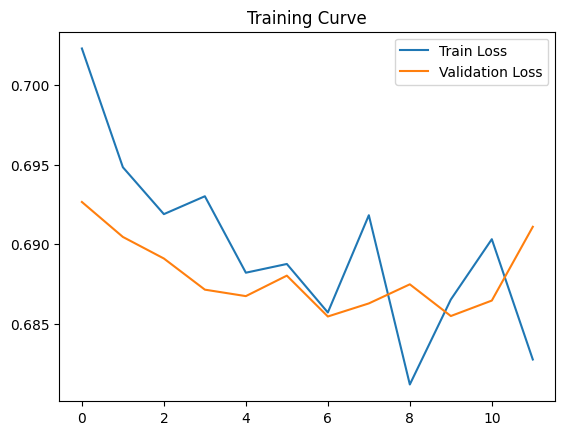

Validation ROC-AUC: 0.5544685990338164

Config: lr=0.001, batch=32, hidden=128, layers=2
Epoch 1 | Train Loss: 0.7065 | Val Loss: 0.6932
Epoch 2 | Train Loss: 0.6964 | Val Loss: 0.6975
Epoch 3 | Train Loss: 0.6952 | Val Loss: 0.6924
Epoch 4 | Train Loss: 0.6964 | Val Loss: 0.6905
Epoch 5 | Train Loss: 0.6959 | Val Loss: 0.6925
Epoch 6 | Train Loss: 0.6909 | Val Loss: 0.6898
Epoch 7 | Train Loss: 0.6921 | Val Loss: 0.6878
Epoch 8 | Train Loss: 0.6906 | Val Loss: 0.6873
Epoch 9 | Train Loss: 0.6897 | Val Loss: 0.6888
Epoch 10 | Train Loss: 0.6902 | Val Loss: 0.6862
Epoch 11 | Train Loss: 0.6879 | Val Loss: 0.6871
Epoch 12 | Train Loss: 0.6890 | Val Loss: 0.6870
Epoch 13 | Train Loss: 0.6947 | Val Loss: 0.6910
Epoch 14 | Train Loss: 0.6900 | Val Loss: 0.6860
Epoch 15 | Train Loss: 0.6855 | Val Loss: 0.6853
Early stopping triggered at epoch 15


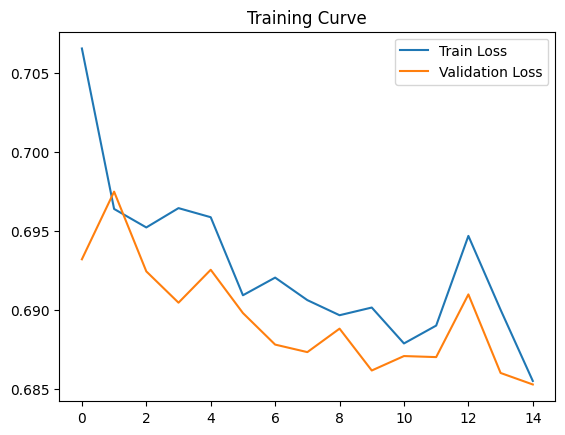

Validation ROC-AUC: 0.5853864734299518

Config: lr=0.0005, batch=16, hidden=64, layers=1
Epoch 1 | Train Loss: 0.6959 | Val Loss: 0.7007
Epoch 2 | Train Loss: 0.6940 | Val Loss: 0.6921
Epoch 3 | Train Loss: 0.6932 | Val Loss: 0.6947
Epoch 4 | Train Loss: 0.6910 | Val Loss: 0.6914
Epoch 5 | Train Loss: 0.6899 | Val Loss: 0.6918
Epoch 6 | Train Loss: 0.6902 | Val Loss: 0.6902
Epoch 7 | Train Loss: 0.6886 | Val Loss: 0.6872
Epoch 8 | Train Loss: 0.6930 | Val Loss: 0.6941
Epoch 9 | Train Loss: 0.6871 | Val Loss: 0.6872
Epoch 10 | Train Loss: 0.6866 | Val Loss: 0.6882
Epoch 11 | Train Loss: 0.6838 | Val Loss: 0.6825
Epoch 12 | Train Loss: 0.6885 | Val Loss: 0.6872
Epoch 13 | Train Loss: 0.6857 | Val Loss: 0.6849
Epoch 14 | Train Loss: 0.6834 | Val Loss: 0.6808
Epoch 15 | Train Loss: 0.6829 | Val Loss: 0.6831
Epoch 16 | Train Loss: 0.6843 | Val Loss: 0.6852
Epoch 17 | Train Loss: 0.6873 | Val Loss: 0.6826
Epoch 18 | Train Loss: 0.6830 | Val Loss: 0.6819
Epoch 19 | Train Loss: 0.6840 | Val Lo

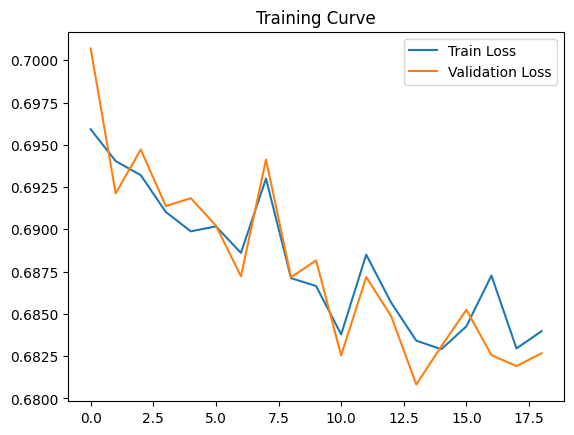

Validation ROC-AUC: 0.6047101449275362

Config: lr=0.0005, batch=16, hidden=64, layers=2
Epoch 1 | Train Loss: 0.6944 | Val Loss: 0.6913
Epoch 2 | Train Loss: 0.6941 | Val Loss: 0.6910
Epoch 3 | Train Loss: 0.6929 | Val Loss: 0.6928
Epoch 4 | Train Loss: 0.6888 | Val Loss: 0.6912
Epoch 5 | Train Loss: 0.6869 | Val Loss: 0.6883
Epoch 6 | Train Loss: 0.6917 | Val Loss: 0.6874
Epoch 7 | Train Loss: 0.6876 | Val Loss: 0.6851
Epoch 8 | Train Loss: 0.6863 | Val Loss: 0.6843
Epoch 9 | Train Loss: 0.6854 | Val Loss: 0.6882
Epoch 10 | Train Loss: 0.6867 | Val Loss: 0.6857
Epoch 11 | Train Loss: 0.6853 | Val Loss: 0.6835
Epoch 12 | Train Loss: 0.6855 | Val Loss: 0.6855
Epoch 13 | Train Loss: 0.6830 | Val Loss: 0.6868
Epoch 14 | Train Loss: 0.6840 | Val Loss: 0.6855
Epoch 15 | Train Loss: 0.6849 | Val Loss: 0.6846
Epoch 16 | Train Loss: 0.6854 | Val Loss: 0.6849
Early stopping triggered at epoch 16


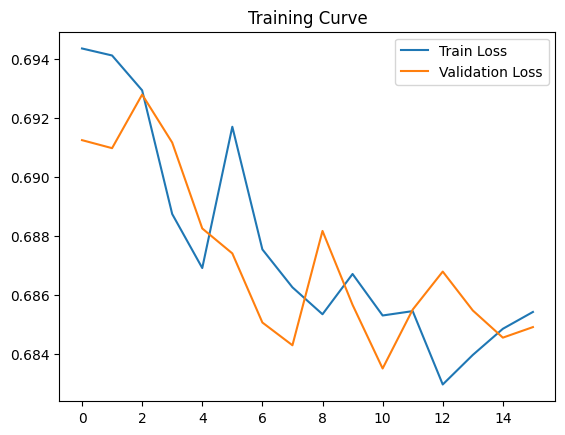

Validation ROC-AUC: 0.5979468599033817

Config: lr=0.0005, batch=16, hidden=128, layers=1
Epoch 1 | Train Loss: 0.6961 | Val Loss: 0.7004
Epoch 2 | Train Loss: 0.6913 | Val Loss: 0.6969
Epoch 3 | Train Loss: 0.6943 | Val Loss: 0.6930
Epoch 4 | Train Loss: 0.6934 | Val Loss: 0.6934
Epoch 5 | Train Loss: 0.6909 | Val Loss: 0.6890
Epoch 6 | Train Loss: 0.6902 | Val Loss: 0.6907
Epoch 7 | Train Loss: 0.6890 | Val Loss: 0.6890
Epoch 8 | Train Loss: 0.6884 | Val Loss: 0.6894
Epoch 9 | Train Loss: 0.6893 | Val Loss: 0.6886
Epoch 10 | Train Loss: 0.6933 | Val Loss: 0.6954
Early stopping triggered at epoch 10


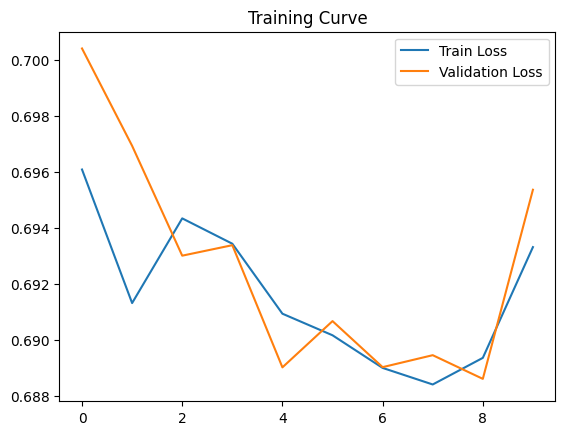

Validation ROC-AUC: 0.538768115942029

Config: lr=0.0005, batch=16, hidden=128, layers=2
Epoch 1 | Train Loss: 0.6975 | Val Loss: 0.6918
Epoch 2 | Train Loss: 0.6934 | Val Loss: 0.7005
Epoch 3 | Train Loss: 0.6921 | Val Loss: 0.6938
Epoch 4 | Train Loss: 0.6908 | Val Loss: 0.6901
Epoch 5 | Train Loss: 0.6912 | Val Loss: 0.6900
Epoch 6 | Train Loss: 0.6891 | Val Loss: 0.6923
Epoch 7 | Train Loss: 0.6889 | Val Loss: 0.6888
Epoch 8 | Train Loss: 0.6905 | Val Loss: 0.6888
Epoch 9 | Train Loss: 0.6928 | Val Loss: 0.7002
Epoch 10 | Train Loss: 0.6899 | Val Loss: 0.6895
Epoch 11 | Train Loss: 0.6880 | Val Loss: 0.6902
Epoch 12 | Train Loss: 0.6869 | Val Loss: 0.6885
Early stopping triggered at epoch 12


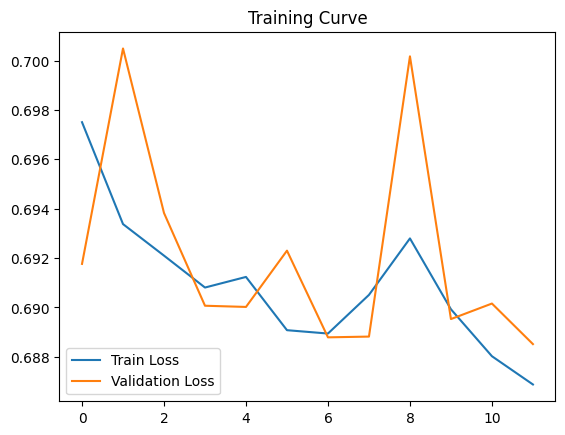

Validation ROC-AUC: 0.5644927536231884

Config: lr=0.0005, batch=32, hidden=64, layers=1
Epoch 1 | Train Loss: 0.6957 | Val Loss: 0.6919
Epoch 2 | Train Loss: 0.6917 | Val Loss: 0.6913
Epoch 3 | Train Loss: 0.6901 | Val Loss: 0.6909
Epoch 4 | Train Loss: 0.6933 | Val Loss: 0.6920
Epoch 5 | Train Loss: 0.6919 | Val Loss: 0.6910
Epoch 6 | Train Loss: 0.6884 | Val Loss: 0.6897
Epoch 7 | Train Loss: 0.6885 | Val Loss: 0.6889
Epoch 8 | Train Loss: 0.6900 | Val Loss: 0.6886
Epoch 9 | Train Loss: 0.6880 | Val Loss: 0.6878
Epoch 10 | Train Loss: 0.6856 | Val Loss: 0.6875
Epoch 11 | Train Loss: 0.6881 | Val Loss: 0.6839
Epoch 12 | Train Loss: 0.6841 | Val Loss: 0.6815
Epoch 13 | Train Loss: 0.6850 | Val Loss: 0.6844
Epoch 14 | Train Loss: 0.6826 | Val Loss: 0.6833
Epoch 15 | Train Loss: 0.6861 | Val Loss: 0.6790
Epoch 16 | Train Loss: 0.6819 | Val Loss: 0.6788
Epoch 17 | Train Loss: 0.6819 | Val Loss: 0.6774
Epoch 18 | Train Loss: 0.6851 | Val Loss: 0.6766
Epoch 19 | Train Loss: 0.6817 | Val Lo

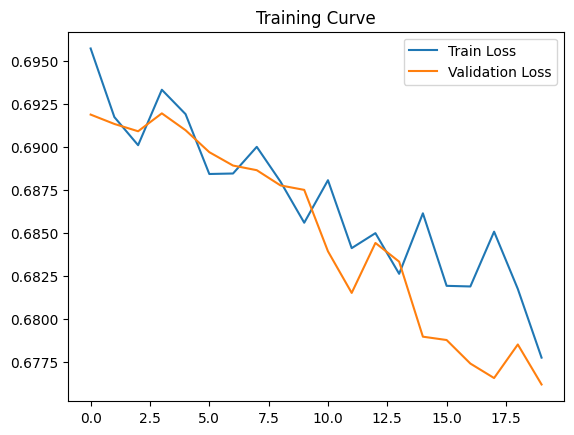

Validation ROC-AUC: 0.6150966183574879

Config: lr=0.0005, batch=32, hidden=64, layers=2
Epoch 1 | Train Loss: 0.6967 | Val Loss: 0.6918
Epoch 2 | Train Loss: 0.6916 | Val Loss: 0.6934
Epoch 3 | Train Loss: 0.6903 | Val Loss: 0.6903
Epoch 4 | Train Loss: 0.6910 | Val Loss: 0.6898
Epoch 5 | Train Loss: 0.6885 | Val Loss: 0.6890
Epoch 6 | Train Loss: 0.6895 | Val Loss: 0.6902
Epoch 7 | Train Loss: 0.6864 | Val Loss: 0.6872
Epoch 8 | Train Loss: 0.6876 | Val Loss: 0.6865
Epoch 9 | Train Loss: 0.6865 | Val Loss: 0.6867
Epoch 10 | Train Loss: 0.6930 | Val Loss: 0.6906
Epoch 11 | Train Loss: 0.6861 | Val Loss: 0.6843
Epoch 12 | Train Loss: 0.6856 | Val Loss: 0.6838
Epoch 13 | Train Loss: 0.6846 | Val Loss: 0.6852
Epoch 14 | Train Loss: 0.6851 | Val Loss: 0.6826
Epoch 15 | Train Loss: 0.6855 | Val Loss: 0.6851
Epoch 16 | Train Loss: 0.6872 | Val Loss: 0.6834
Epoch 17 | Train Loss: 0.6869 | Val Loss: 0.6797
Epoch 18 | Train Loss: 0.6870 | Val Loss: 0.6802
Epoch 19 | Train Loss: 0.6845 | Val Lo

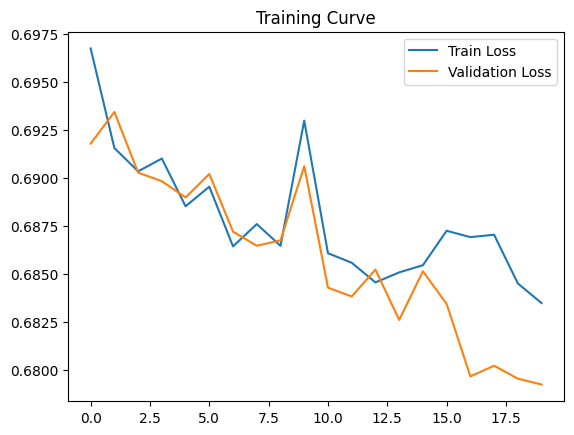

Validation ROC-AUC: 0.5951690821256039

Config: lr=0.0005, batch=32, hidden=128, layers=1
Epoch 1 | Train Loss: 0.6980 | Val Loss: 0.6926
Epoch 2 | Train Loss: 0.6959 | Val Loss: 0.6918
Epoch 3 | Train Loss: 0.6951 | Val Loss: 0.6925
Epoch 4 | Train Loss: 0.6906 | Val Loss: 0.6889
Epoch 5 | Train Loss: 0.6914 | Val Loss: 0.6877
Epoch 6 | Train Loss: 0.6856 | Val Loss: 0.6854
Epoch 7 | Train Loss: 0.6873 | Val Loss: 0.6827
Epoch 8 | Train Loss: 0.6909 | Val Loss: 0.6918
Epoch 9 | Train Loss: 0.6873 | Val Loss: 0.6870
Epoch 10 | Train Loss: 0.6857 | Val Loss: 0.6850
Epoch 11 | Train Loss: 0.6891 | Val Loss: 0.6994
Epoch 12 | Train Loss: 0.6900 | Val Loss: 0.6884
Early stopping triggered at epoch 12


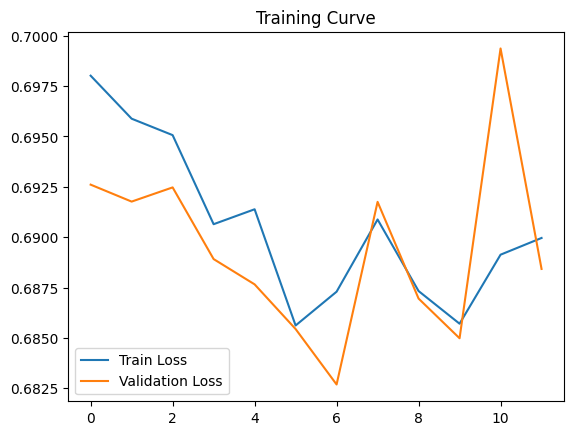

Validation ROC-AUC: 0.5526570048309178

Config: lr=0.0005, batch=32, hidden=128, layers=2
Epoch 1 | Train Loss: 0.6964 | Val Loss: 0.6932
Epoch 2 | Train Loss: 0.6885 | Val Loss: 0.6944
Epoch 3 | Train Loss: 0.7024 | Val Loss: 0.6905
Epoch 4 | Train Loss: 0.6897 | Val Loss: 0.6912
Epoch 5 | Train Loss: 0.6891 | Val Loss: 0.6891
Epoch 6 | Train Loss: 0.6874 | Val Loss: 0.6885
Epoch 7 | Train Loss: 0.6873 | Val Loss: 0.6870
Epoch 8 | Train Loss: 0.6871 | Val Loss: 0.6838
Epoch 9 | Train Loss: 0.6875 | Val Loss: 0.6856
Epoch 10 | Train Loss: 0.6855 | Val Loss: 0.6888
Epoch 11 | Train Loss: 0.6856 | Val Loss: 0.6906
Epoch 12 | Train Loss: 0.6878 | Val Loss: 0.6829
Epoch 13 | Train Loss: 0.6866 | Val Loss: 0.6845
Early stopping triggered at epoch 13


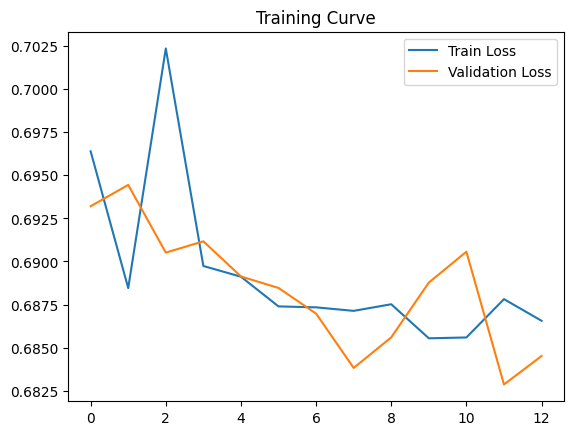

Validation ROC-AUC: 0.577415458937198

Best config for RNN: {'lr': 0.0005, 'batch_size': 32, 'hidden_size': 64, 'layers': 1}
Best validation AUC: 0.6151

===== Tuning LSTM =====

Config: lr=0.001, batch=16, hidden=64, layers=1


c:\Users\VARADHARAJAN K\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Epoch 1 | Train Loss: 0.6928 | Val Loss: 0.6928
Epoch 2 | Train Loss: 0.6932 | Val Loss: 0.6962
Epoch 3 | Train Loss: 0.6905 | Val Loss: 0.6942
Epoch 4 | Train Loss: 0.6906 | Val Loss: 0.6929
Epoch 5 | Train Loss: 0.6926 | Val Loss: 0.6925
Epoch 6 | Train Loss: 0.6903 | Val Loss: 0.6933
Early stopping triggered at epoch 6


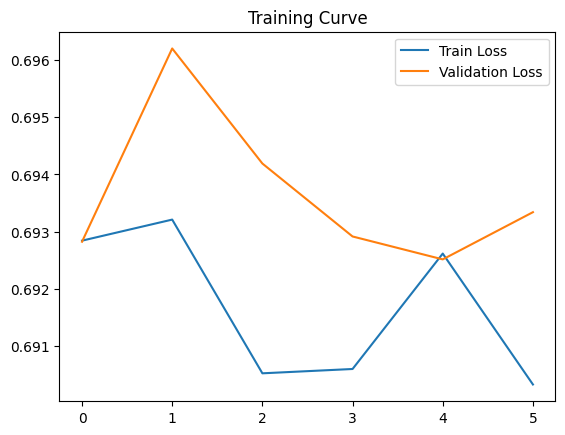

Validation ROC-AUC: 0.5361111111111111

Config: lr=0.001, batch=16, hidden=64, layers=2
Epoch 1 | Train Loss: 0.6930 | Val Loss: 0.6926
Epoch 2 | Train Loss: 0.6919 | Val Loss: 0.6927
Epoch 3 | Train Loss: 0.6923 | Val Loss: 0.6941
Epoch 4 | Train Loss: 0.6904 | Val Loss: 0.6955
Epoch 5 | Train Loss: 0.6904 | Val Loss: 0.6949
Epoch 6 | Train Loss: 0.6915 | Val Loss: 0.6963
Early stopping triggered at epoch 6


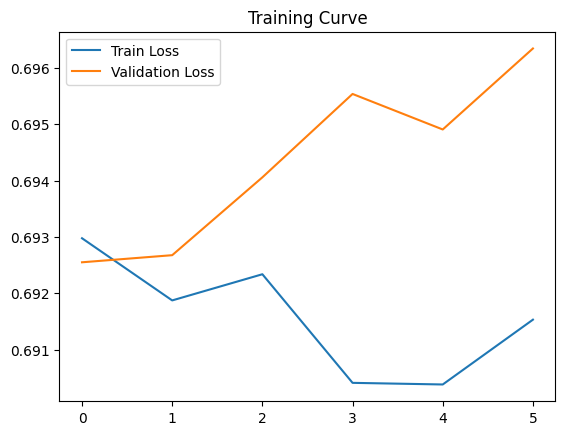

Validation ROC-AUC: 0.513768115942029

Config: lr=0.001, batch=16, hidden=128, layers=1


c:\Users\VARADHARAJAN K\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Epoch 1 | Train Loss: 0.6996 | Val Loss: 0.6974
Epoch 2 | Train Loss: 0.6936 | Val Loss: 0.6931
Epoch 3 | Train Loss: 0.6921 | Val Loss: 0.6925
Epoch 4 | Train Loss: 0.6901 | Val Loss: 0.6929
Epoch 5 | Train Loss: 0.6896 | Val Loss: 0.6936
Epoch 6 | Train Loss: 0.6901 | Val Loss: 0.6940
Epoch 7 | Train Loss: 0.6893 | Val Loss: 0.6942
Early stopping triggered at epoch 7


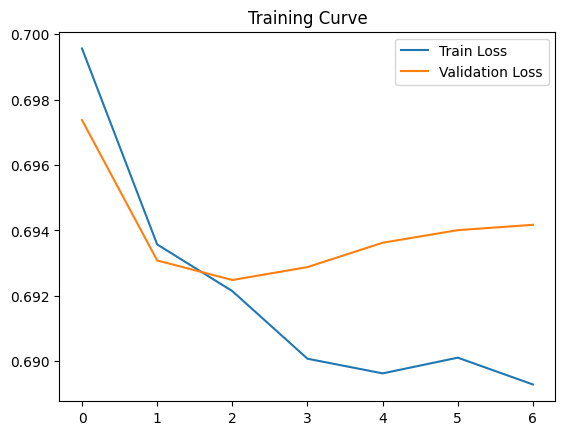

Validation ROC-AUC: 0.5477657004830918

Config: lr=0.001, batch=16, hidden=128, layers=2
Epoch 1 | Train Loss: 0.6921 | Val Loss: 0.6940
Epoch 2 | Train Loss: 0.6903 | Val Loss: 0.6940
Epoch 3 | Train Loss: 0.6923 | Val Loss: 0.6947
Epoch 4 | Train Loss: 0.6903 | Val Loss: 0.6927
Epoch 5 | Train Loss: 0.6896 | Val Loss: 0.6976
Epoch 6 | Train Loss: 0.6915 | Val Loss: 0.6920
Epoch 7 | Train Loss: 0.6894 | Val Loss: 0.6922
Epoch 8 | Train Loss: 0.6891 | Val Loss: 0.6942
Epoch 9 | Train Loss: 0.6913 | Val Loss: 0.6981
Early stopping triggered at epoch 9


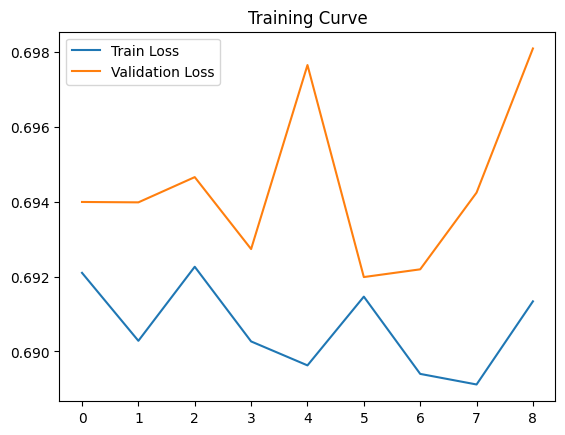

Validation ROC-AUC: 0.46618357487922707

Config: lr=0.001, batch=32, hidden=64, layers=1


c:\Users\VARADHARAJAN K\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Epoch 1 | Train Loss: 0.6907 | Val Loss: 0.6961
Epoch 2 | Train Loss: 0.6907 | Val Loss: 0.6931
Epoch 3 | Train Loss: 0.6932 | Val Loss: 0.6947
Epoch 4 | Train Loss: 0.6898 | Val Loss: 0.6921
Epoch 5 | Train Loss: 0.6883 | Val Loss: 0.6934
Epoch 6 | Train Loss: 0.6879 | Val Loss: 0.6918
Epoch 7 | Train Loss: 0.6879 | Val Loss: 0.6918
Epoch 8 | Train Loss: 0.6887 | Val Loss: 0.6915
Epoch 9 | Train Loss: 0.6878 | Val Loss: 0.6890
Epoch 10 | Train Loss: 0.6880 | Val Loss: 0.6884
Epoch 11 | Train Loss: 0.6867 | Val Loss: 0.6871
Epoch 12 | Train Loss: 0.6862 | Val Loss: 0.6869
Epoch 13 | Train Loss: 0.6852 | Val Loss: 0.6864
Epoch 14 | Train Loss: 0.6838 | Val Loss: 0.6858
Epoch 15 | Train Loss: 0.6838 | Val Loss: 0.6852
Epoch 16 | Train Loss: 0.6857 | Val Loss: 0.6853
Epoch 17 | Train Loss: 0.6844 | Val Loss: 0.6840
Epoch 18 | Train Loss: 0.6845 | Val Loss: 0.6833
Epoch 19 | Train Loss: 0.6814 | Val Loss: 0.6877
Epoch 20 | Train Loss: 0.6841 | Val Loss: 0.6826


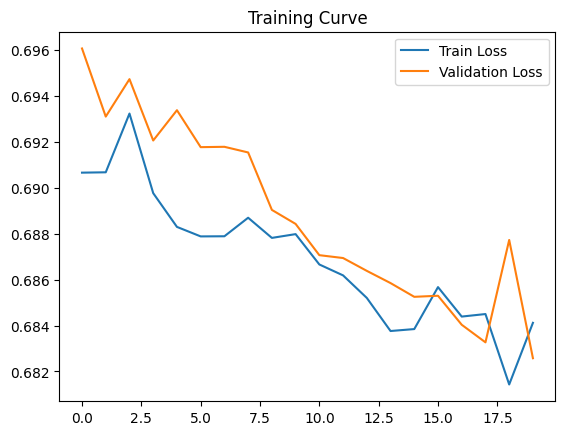

Validation ROC-AUC: 0.6251207729468599

Config: lr=0.001, batch=32, hidden=64, layers=2
Epoch 1 | Train Loss: 0.6966 | Val Loss: 0.6927
Epoch 2 | Train Loss: 0.6908 | Val Loss: 0.6932
Epoch 3 | Train Loss: 0.6911 | Val Loss: 0.6942
Epoch 4 | Train Loss: 0.6910 | Val Loss: 0.6942
Epoch 5 | Train Loss: 0.6893 | Val Loss: 0.6933
Epoch 6 | Train Loss: 0.6888 | Val Loss: 0.6934
Early stopping triggered at epoch 6


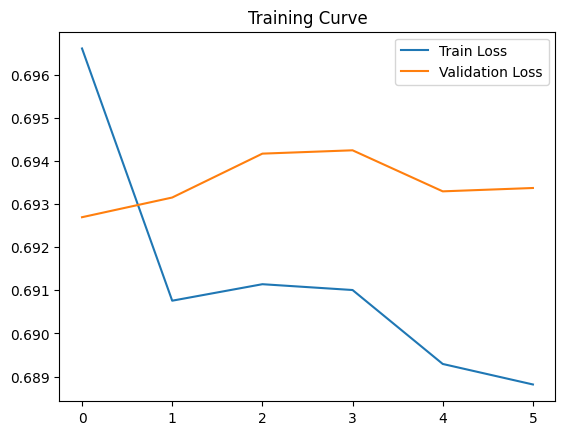

Validation ROC-AUC: 0.5254830917874396

Config: lr=0.001, batch=32, hidden=128, layers=1


c:\Users\VARADHARAJAN K\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Epoch 1 | Train Loss: 0.6970 | Val Loss: 0.6922
Epoch 2 | Train Loss: 0.6934 | Val Loss: 0.6922
Epoch 3 | Train Loss: 0.6894 | Val Loss: 0.6923
Epoch 4 | Train Loss: 0.6890 | Val Loss: 0.6927
Epoch 5 | Train Loss: 0.6905 | Val Loss: 0.6923
Epoch 6 | Train Loss: 0.6895 | Val Loss: 0.6927
Early stopping triggered at epoch 6


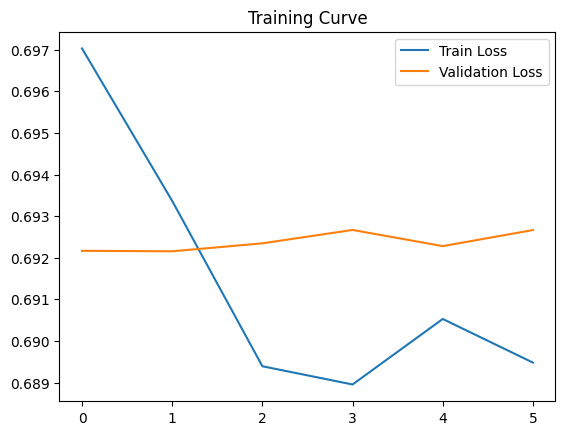

Validation ROC-AUC: 0.5433574879227052

Config: lr=0.001, batch=32, hidden=128, layers=2
Epoch 1 | Train Loss: 0.6958 | Val Loss: 0.6930
Epoch 2 | Train Loss: 0.6924 | Val Loss: 0.6938
Epoch 3 | Train Loss: 0.6915 | Val Loss: 0.6920
Epoch 4 | Train Loss: 0.6914 | Val Loss: 0.6920
Epoch 5 | Train Loss: 0.6902 | Val Loss: 0.6930
Epoch 6 | Train Loss: 0.6893 | Val Loss: 0.6952
Early stopping triggered at epoch 6


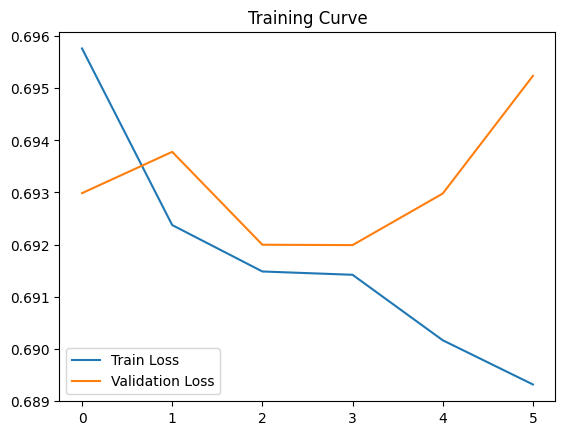

Validation ROC-AUC: 0.5234299516908213

Config: lr=0.0005, batch=16, hidden=64, layers=1


c:\Users\VARADHARAJAN K\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Epoch 1 | Train Loss: 0.6972 | Val Loss: 0.6934
Epoch 2 | Train Loss: 0.6912 | Val Loss: 0.6946
Epoch 3 | Train Loss: 0.6892 | Val Loss: 0.6930
Epoch 4 | Train Loss: 0.6896 | Val Loss: 0.6923
Epoch 5 | Train Loss: 0.6904 | Val Loss: 0.6935
Epoch 6 | Train Loss: 0.6886 | Val Loss: 0.6945
Epoch 7 | Train Loss: 0.6889 | Val Loss: 0.6932
Epoch 8 | Train Loss: 0.6880 | Val Loss: 0.6977
Epoch 9 | Train Loss: 0.6883 | Val Loss: 0.6910
Epoch 10 | Train Loss: 0.6893 | Val Loss: 0.6944
Epoch 11 | Train Loss: 0.6879 | Val Loss: 0.6922
Epoch 12 | Train Loss: 0.6874 | Val Loss: 0.6910
Epoch 13 | Train Loss: 0.6863 | Val Loss: 0.6909
Epoch 14 | Train Loss: 0.6848 | Val Loss: 0.6872
Epoch 15 | Train Loss: 0.6854 | Val Loss: 0.6882
Epoch 16 | Train Loss: 0.6851 | Val Loss: 0.6893
Epoch 17 | Train Loss: 0.6859 | Val Loss: 0.6880
Epoch 18 | Train Loss: 0.6817 | Val Loss: 0.6931
Epoch 19 | Train Loss: 0.6868 | Val Loss: 0.6882
Early stopping triggered at epoch 19


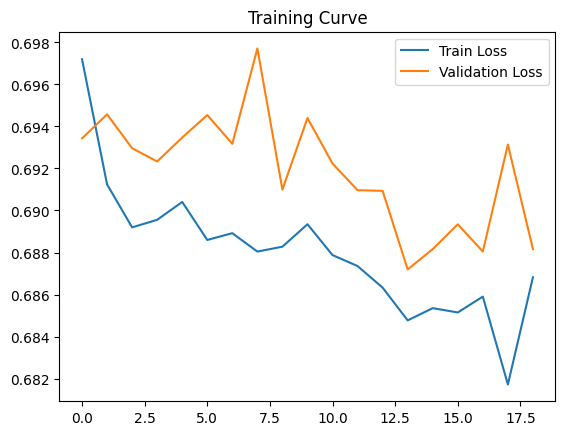

Validation ROC-AUC: 0.6117149758454106

Config: lr=0.0005, batch=16, hidden=64, layers=2
Epoch 1 | Train Loss: 0.6935 | Val Loss: 0.6948
Epoch 2 | Train Loss: 0.6918 | Val Loss: 0.6945
Epoch 3 | Train Loss: 0.6906 | Val Loss: 0.6940
Epoch 4 | Train Loss: 0.6888 | Val Loss: 0.6946
Epoch 5 | Train Loss: 0.6887 | Val Loss: 0.6930
Epoch 6 | Train Loss: 0.6888 | Val Loss: 0.6945
Epoch 7 | Train Loss: 0.6907 | Val Loss: 0.6943
Epoch 8 | Train Loss: 0.6886 | Val Loss: 0.6944
Epoch 9 | Train Loss: 0.6880 | Val Loss: 0.6935
Epoch 10 | Train Loss: 0.6878 | Val Loss: 0.6937
Early stopping triggered at epoch 10


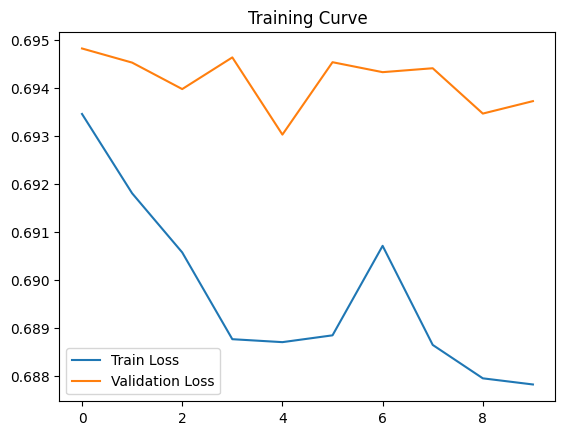

Validation ROC-AUC: 0.5559178743961353

Config: lr=0.0005, batch=16, hidden=128, layers=1


c:\Users\VARADHARAJAN K\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Epoch 1 | Train Loss: 0.6921 | Val Loss: 0.6923
Epoch 2 | Train Loss: 0.6891 | Val Loss: 0.6972
Epoch 3 | Train Loss: 0.6914 | Val Loss: 0.6921
Epoch 4 | Train Loss: 0.6899 | Val Loss: 0.6916
Epoch 5 | Train Loss: 0.6874 | Val Loss: 0.6954
Epoch 6 | Train Loss: 0.6906 | Val Loss: 0.6914
Early stopping triggered at epoch 6


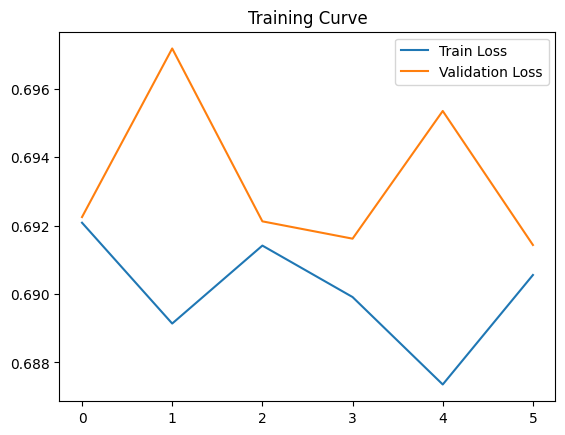

Validation ROC-AUC: 0.5522946859903382

Config: lr=0.0005, batch=16, hidden=128, layers=2
Epoch 1 | Train Loss: 0.6930 | Val Loss: 0.6979
Epoch 2 | Train Loss: 0.6900 | Val Loss: 0.6930
Epoch 3 | Train Loss: 0.6901 | Val Loss: 0.6934
Epoch 4 | Train Loss: 0.6893 | Val Loss: 0.6935
Epoch 5 | Train Loss: 0.6901 | Val Loss: 0.6955
Epoch 6 | Train Loss: 0.6911 | Val Loss: 0.6937
Epoch 7 | Train Loss: 0.6904 | Val Loss: 0.6932
Early stopping triggered at epoch 7


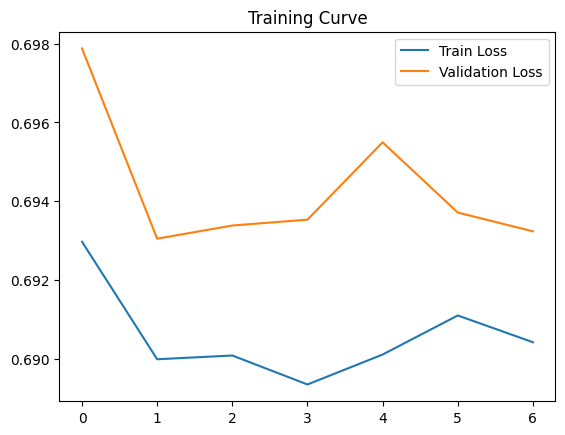

Validation ROC-AUC: 0.5396135265700484

Config: lr=0.0005, batch=32, hidden=64, layers=1


c:\Users\VARADHARAJAN K\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Epoch 1 | Train Loss: 0.6946 | Val Loss: 0.6922
Epoch 2 | Train Loss: 0.6913 | Val Loss: 0.6935
Epoch 3 | Train Loss: 0.6908 | Val Loss: 0.6934
Epoch 4 | Train Loss: 0.6910 | Val Loss: 0.6927
Epoch 5 | Train Loss: 0.6891 | Val Loss: 0.6925
Epoch 6 | Train Loss: 0.6907 | Val Loss: 0.6920
Early stopping triggered at epoch 6


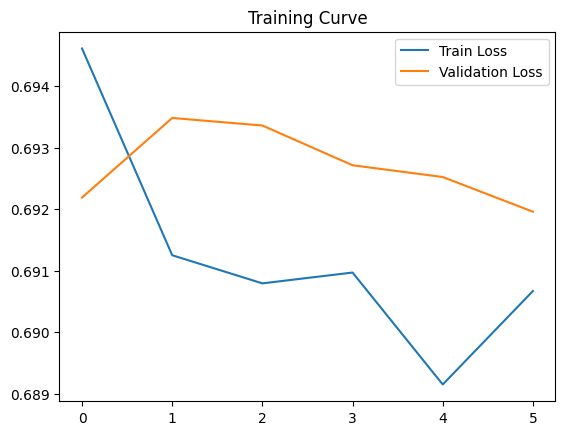

Validation ROC-AUC: 0.5294685990338164

Config: lr=0.0005, batch=32, hidden=64, layers=2
Epoch 1 | Train Loss: 0.6906 | Val Loss: 0.6932
Epoch 2 | Train Loss: 0.6918 | Val Loss: 0.6919
Epoch 3 | Train Loss: 0.6894 | Val Loss: 0.6923
Epoch 4 | Train Loss: 0.6888 | Val Loss: 0.6919
Epoch 5 | Train Loss: 0.6894 | Val Loss: 0.6925
Epoch 6 | Train Loss: 0.6894 | Val Loss: 0.6919
Epoch 7 | Train Loss: 0.6882 | Val Loss: 0.6916
Early stopping triggered at epoch 7


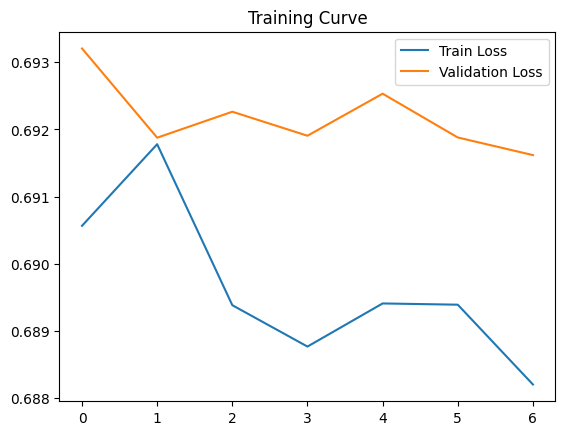

Validation ROC-AUC: 0.5326086956521738

Config: lr=0.0005, batch=32, hidden=128, layers=1


c:\Users\VARADHARAJAN K\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Epoch 1 | Train Loss: 0.6956 | Val Loss: 0.6957
Epoch 2 | Train Loss: 0.6925 | Val Loss: 0.6919
Epoch 3 | Train Loss: 0.6905 | Val Loss: 0.6932
Epoch 4 | Train Loss: 0.6913 | Val Loss: 0.6919
Epoch 5 | Train Loss: 0.6888 | Val Loss: 0.6913
Epoch 6 | Train Loss: 0.6896 | Val Loss: 0.6920
Epoch 7 | Train Loss: 0.6908 | Val Loss: 0.6914
Early stopping triggered at epoch 7


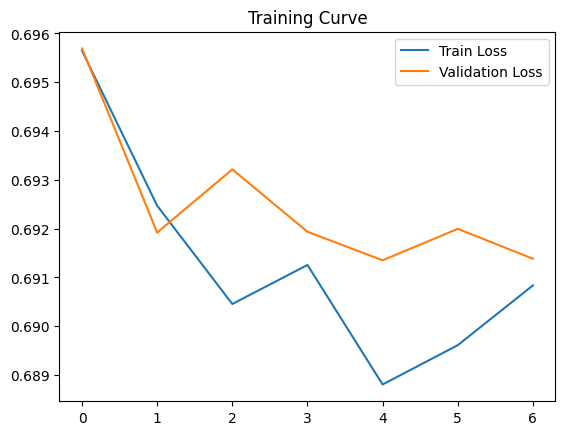

Validation ROC-AUC: 0.5527777777777778

Config: lr=0.0005, batch=32, hidden=128, layers=2
Epoch 1 | Train Loss: 0.6943 | Val Loss: 0.6941
Epoch 2 | Train Loss: 0.6884 | Val Loss: 0.6927
Epoch 3 | Train Loss: 0.6893 | Val Loss: 0.6924
Epoch 4 | Train Loss: 0.6895 | Val Loss: 0.6928
Epoch 5 | Train Loss: 0.6877 | Val Loss: 0.6925
Epoch 6 | Train Loss: 0.6890 | Val Loss: 0.6921
Epoch 7 | Train Loss: 0.6882 | Val Loss: 0.6925
Early stopping triggered at epoch 7


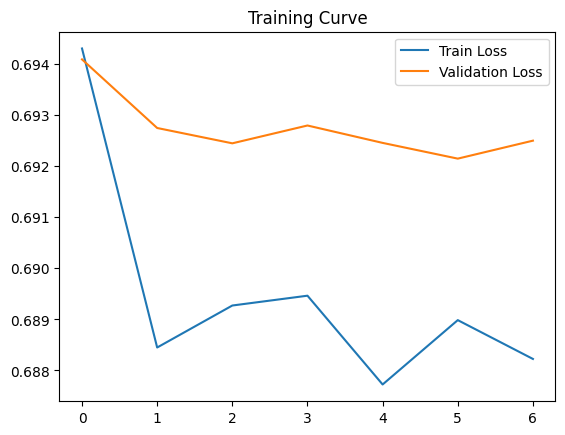

Validation ROC-AUC: 0.5365942028985506

Best config for LSTM: {'lr': 0.001, 'batch_size': 32, 'hidden_size': 64, 'layers': 1}
Best validation AUC: 0.6251

===== Tuning GRU =====

Config: lr=0.001, batch=16, hidden=64, layers=1


c:\Users\VARADHARAJAN K\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Epoch 1 | Train Loss: 0.7077 | Val Loss: 0.6976
Epoch 2 | Train Loss: 0.6960 | Val Loss: 0.6928
Epoch 3 | Train Loss: 0.6869 | Val Loss: 0.6958
Epoch 4 | Train Loss: 0.6797 | Val Loss: 0.6733
Epoch 5 | Train Loss: 0.6511 | Val Loss: 0.6269
Epoch 6 | Train Loss: 0.5667 | Val Loss: 0.5078
Epoch 7 | Train Loss: 0.4665 | Val Loss: 0.5188
Epoch 8 | Train Loss: 0.3897 | Val Loss: 0.4374
Epoch 9 | Train Loss: 0.4174 | Val Loss: 0.4281
Epoch 10 | Train Loss: 0.3770 | Val Loss: 0.4165
Epoch 11 | Train Loss: 0.3538 | Val Loss: 0.3987
Epoch 12 | Train Loss: 0.3289 | Val Loss: 0.3956
Epoch 13 | Train Loss: 0.3129 | Val Loss: 0.4006
Epoch 14 | Train Loss: 0.2969 | Val Loss: 0.3669
Epoch 15 | Train Loss: 0.2858 | Val Loss: 0.3363
Epoch 16 | Train Loss: 0.2721 | Val Loss: 0.3136
Epoch 17 | Train Loss: 0.2393 | Val Loss: 0.3077
Epoch 18 | Train Loss: 0.2317 | Val Loss: 0.2797
Epoch 19 | Train Loss: 0.2370 | Val Loss: 0.3425
Epoch 20 | Train Loss: 0.2137 | Val Loss: 0.3407


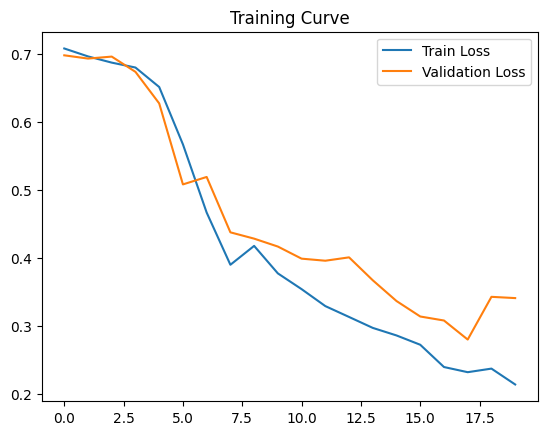

Validation ROC-AUC: 0.9454106280193236

Config: lr=0.001, batch=16, hidden=64, layers=2
Epoch 1 | Train Loss: 0.6966 | Val Loss: 0.6943
Epoch 2 | Train Loss: 0.6929 | Val Loss: 0.6971
Epoch 3 | Train Loss: 0.6903 | Val Loss: 0.6932
Epoch 4 | Train Loss: 0.6978 | Val Loss: 0.6954
Epoch 5 | Train Loss: 0.6910 | Val Loss: 0.6913
Epoch 6 | Train Loss: 0.6855 | Val Loss: 0.6891
Epoch 7 | Train Loss: 0.6518 | Val Loss: 0.6246
Epoch 8 | Train Loss: 0.5482 | Val Loss: 0.5385
Epoch 9 | Train Loss: 0.4678 | Val Loss: 0.4705
Epoch 10 | Train Loss: 0.3911 | Val Loss: 0.4351
Epoch 11 | Train Loss: 0.3478 | Val Loss: 0.4282
Epoch 12 | Train Loss: 0.3213 | Val Loss: 0.3746
Epoch 13 | Train Loss: 0.2846 | Val Loss: 0.3426
Epoch 14 | Train Loss: 0.3057 | Val Loss: 0.3410
Epoch 15 | Train Loss: 0.2896 | Val Loss: 0.3883
Epoch 16 | Train Loss: 0.2575 | Val Loss: 0.3011
Epoch 17 | Train Loss: 0.2216 | Val Loss: 0.2890
Epoch 18 | Train Loss: 0.1948 | Val Loss: 0.2694
Epoch 19 | Train Loss: 0.1888 | Val Los

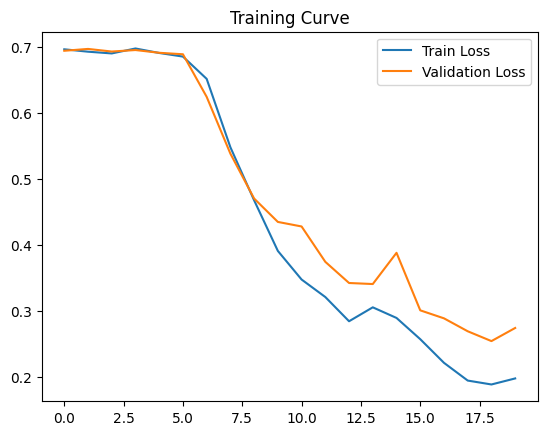

Validation ROC-AUC: 0.9502415458937198

Config: lr=0.001, batch=16, hidden=128, layers=1


c:\Users\VARADHARAJAN K\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Epoch 1 | Train Loss: 0.6966 | Val Loss: 0.6921
Epoch 2 | Train Loss: 0.6923 | Val Loss: 0.7003
Epoch 3 | Train Loss: 0.6961 | Val Loss: 0.6952
Epoch 4 | Train Loss: 0.6885 | Val Loss: 0.6861
Epoch 5 | Train Loss: 0.6393 | Val Loss: 0.6212
Epoch 6 | Train Loss: 0.4976 | Val Loss: 0.4310
Epoch 7 | Train Loss: 0.4120 | Val Loss: 0.4108
Epoch 8 | Train Loss: 0.3656 | Val Loss: 0.3838
Epoch 9 | Train Loss: 0.3550 | Val Loss: 0.4006
Epoch 10 | Train Loss: 0.3396 | Val Loss: 0.3694
Epoch 11 | Train Loss: 0.3156 | Val Loss: 0.3443
Epoch 12 | Train Loss: 0.2812 | Val Loss: 0.3582
Epoch 13 | Train Loss: 0.2963 | Val Loss: 0.3293
Epoch 14 | Train Loss: 0.2896 | Val Loss: 0.3355
Epoch 15 | Train Loss: 0.2523 | Val Loss: 0.3623
Epoch 16 | Train Loss: 0.2348 | Val Loss: 0.3445
Epoch 17 | Train Loss: 0.2222 | Val Loss: 0.3066
Epoch 18 | Train Loss: 0.1958 | Val Loss: 0.3189
Epoch 19 | Train Loss: 0.1817 | Val Loss: 0.2876
Epoch 20 | Train Loss: 0.1829 | Val Loss: 0.4257


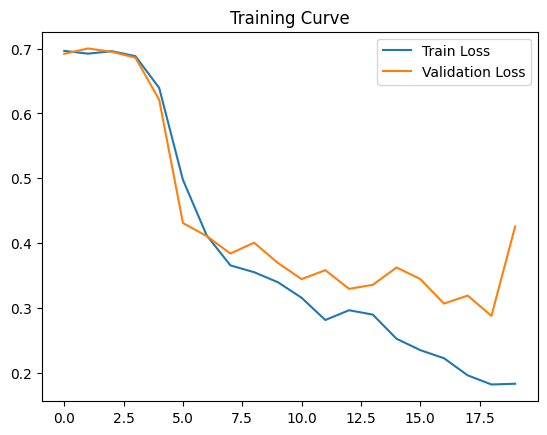

Validation ROC-AUC: 0.9402173913043479

Config: lr=0.001, batch=16, hidden=128, layers=2
Epoch 1 | Train Loss: 0.6980 | Val Loss: 0.6997
Epoch 2 | Train Loss: 0.6954 | Val Loss: 0.6923
Epoch 3 | Train Loss: 0.6932 | Val Loss: 0.6946
Epoch 4 | Train Loss: 0.6892 | Val Loss: 0.6940
Epoch 5 | Train Loss: 0.6872 | Val Loss: 0.6967
Epoch 6 | Train Loss: 0.6902 | Val Loss: 0.6959
Epoch 7 | Train Loss: 0.6794 | Val Loss: 0.7037
Early stopping triggered at epoch 7


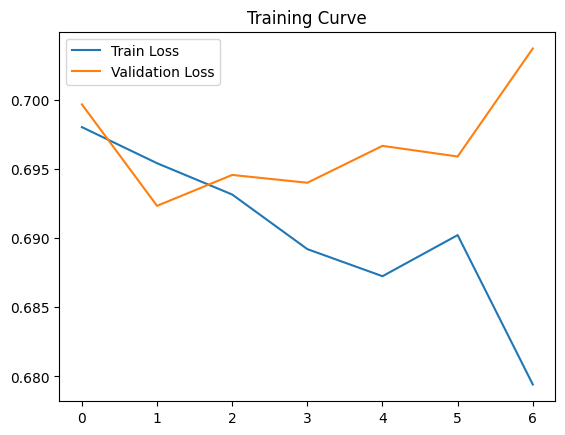

Validation ROC-AUC: 0.5756038647342995

Config: lr=0.001, batch=32, hidden=64, layers=1


c:\Users\VARADHARAJAN K\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Epoch 1 | Train Loss: 0.7010 | Val Loss: 0.6988
Epoch 2 | Train Loss: 0.6936 | Val Loss: 0.6918
Epoch 3 | Train Loss: 0.6928 | Val Loss: 0.6934
Epoch 4 | Train Loss: 0.6930 | Val Loss: 0.6923
Epoch 5 | Train Loss: 0.6845 | Val Loss: 0.6920
Epoch 6 | Train Loss: 0.6828 | Val Loss: 0.6847
Epoch 7 | Train Loss: 0.6710 | Val Loss: 0.6652
Epoch 8 | Train Loss: 0.6408 | Val Loss: 0.6014
Epoch 9 | Train Loss: 0.5042 | Val Loss: 0.5057
Epoch 10 | Train Loss: 0.4425 | Val Loss: 0.4351
Epoch 11 | Train Loss: 0.3942 | Val Loss: 0.4370
Epoch 12 | Train Loss: 0.4022 | Val Loss: 0.4314
Epoch 13 | Train Loss: 0.3767 | Val Loss: 0.4195
Epoch 14 | Train Loss: 0.3608 | Val Loss: 0.4173
Epoch 15 | Train Loss: 0.3363 | Val Loss: 0.4310
Epoch 16 | Train Loss: 0.2967 | Val Loss: 0.4035
Epoch 17 | Train Loss: 0.3278 | Val Loss: 0.3671
Epoch 18 | Train Loss: 0.2941 | Val Loss: 0.3664
Epoch 19 | Train Loss: 0.2726 | Val Loss: 0.3686
Epoch 20 | Train Loss: 0.2727 | Val Loss: 0.3827


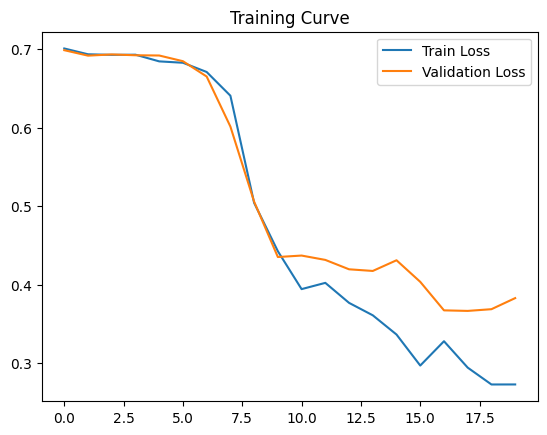

Validation ROC-AUC: 0.9204106280193238

Config: lr=0.001, batch=32, hidden=64, layers=2
Epoch 1 | Train Loss: 0.6958 | Val Loss: 0.7018
Epoch 2 | Train Loss: 0.6898 | Val Loss: 0.6917
Epoch 3 | Train Loss: 0.6896 | Val Loss: 0.6913
Epoch 4 | Train Loss: 0.6892 | Val Loss: 0.6903
Epoch 5 | Train Loss: 0.6845 | Val Loss: 0.6784
Epoch 6 | Train Loss: 0.6568 | Val Loss: 0.5843
Epoch 7 | Train Loss: 0.5554 | Val Loss: 0.4981
Epoch 8 | Train Loss: 0.5106 | Val Loss: 0.5206
Epoch 9 | Train Loss: 0.4476 | Val Loss: 0.5134
Epoch 10 | Train Loss: 0.4514 | Val Loss: 0.4370
Epoch 11 | Train Loss: 0.3962 | Val Loss: 0.3983
Epoch 12 | Train Loss: 0.3455 | Val Loss: 0.3949
Epoch 13 | Train Loss: 0.3287 | Val Loss: 0.3786
Epoch 14 | Train Loss: 0.3305 | Val Loss: 0.3965
Epoch 15 | Train Loss: 0.3020 | Val Loss: 0.3667
Epoch 16 | Train Loss: 0.2759 | Val Loss: 0.3668
Epoch 17 | Train Loss: 0.2712 | Val Loss: 0.3224
Epoch 18 | Train Loss: 0.2495 | Val Loss: 0.2879
Epoch 19 | Train Loss: 0.2266 | Val Los

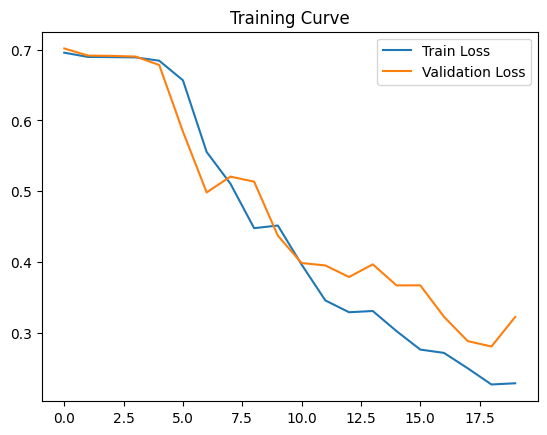

Validation ROC-AUC: 0.9431159420289854

Config: lr=0.001, batch=32, hidden=128, layers=1


c:\Users\VARADHARAJAN K\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Epoch 1 | Train Loss: 0.6976 | Val Loss: 0.6962
Epoch 2 | Train Loss: 0.6927 | Val Loss: 0.6926
Epoch 3 | Train Loss: 0.6904 | Val Loss: 0.7037
Epoch 4 | Train Loss: 0.6917 | Val Loss: 0.6922
Epoch 5 | Train Loss: 0.6923 | Val Loss: 0.6914
Epoch 6 | Train Loss: 0.6883 | Val Loss: 0.6951
Epoch 7 | Train Loss: 0.6824 | Val Loss: 0.6664
Epoch 8 | Train Loss: 0.6353 | Val Loss: 0.7937
Epoch 9 | Train Loss: 0.5512 | Val Loss: 0.4786
Epoch 10 | Train Loss: 0.4870 | Val Loss: 0.4568
Epoch 11 | Train Loss: 0.4075 | Val Loss: 0.4318
Epoch 12 | Train Loss: 0.3916 | Val Loss: 0.4282
Epoch 13 | Train Loss: 0.3595 | Val Loss: 0.4732
Epoch 14 | Train Loss: 0.3389 | Val Loss: 0.4026
Epoch 15 | Train Loss: 0.3405 | Val Loss: 0.3887
Epoch 16 | Train Loss: 0.3068 | Val Loss: 0.3288
Epoch 17 | Train Loss: 0.3365 | Val Loss: 0.3615
Epoch 18 | Train Loss: 0.2711 | Val Loss: 0.3394
Epoch 19 | Train Loss: 0.2773 | Val Loss: 0.3425
Epoch 20 | Train Loss: 0.2596 | Val Loss: 0.3344


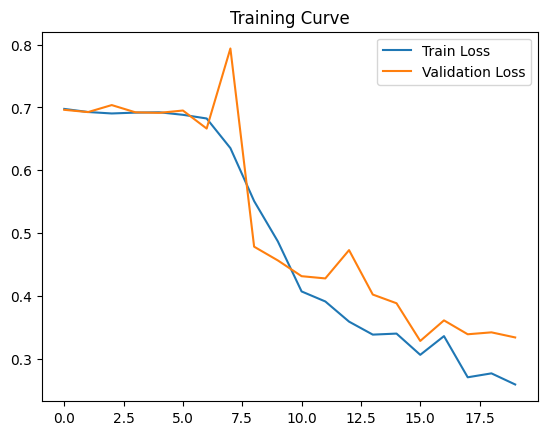

Validation ROC-AUC: 0.932367149758454

Config: lr=0.001, batch=32, hidden=128, layers=2
Epoch 1 | Train Loss: 0.6964 | Val Loss: 0.6990
Epoch 2 | Train Loss: 0.6977 | Val Loss: 0.6927
Epoch 3 | Train Loss: 0.6972 | Val Loss: 0.6916
Epoch 4 | Train Loss: 0.6914 | Val Loss: 0.6918
Epoch 5 | Train Loss: 0.6906 | Val Loss: 0.6950
Epoch 6 | Train Loss: 0.6919 | Val Loss: 0.6938
Epoch 7 | Train Loss: 0.6912 | Val Loss: 0.6916
Epoch 8 | Train Loss: 0.6890 | Val Loss: 0.6961
Early stopping triggered at epoch 8


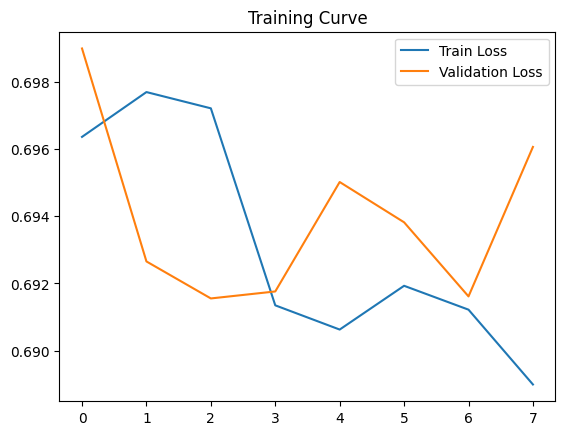

Validation ROC-AUC: 0.5305555555555556

Config: lr=0.0005, batch=16, hidden=64, layers=1


c:\Users\VARADHARAJAN K\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Epoch 1 | Train Loss: 0.6939 | Val Loss: 0.6954
Epoch 2 | Train Loss: 0.6916 | Val Loss: 0.6965
Epoch 3 | Train Loss: 0.6939 | Val Loss: 0.6900
Epoch 4 | Train Loss: 0.6843 | Val Loss: 0.6850
Epoch 5 | Train Loss: 0.6759 | Val Loss: 0.6838
Epoch 6 | Train Loss: 0.6578 | Val Loss: 0.6249
Epoch 7 | Train Loss: 0.5519 | Val Loss: 0.4597
Epoch 8 | Train Loss: 0.4250 | Val Loss: 0.4430
Epoch 9 | Train Loss: 0.4083 | Val Loss: 0.4336
Epoch 10 | Train Loss: 0.3560 | Val Loss: 0.4151
Epoch 11 | Train Loss: 0.3500 | Val Loss: 0.3904
Epoch 12 | Train Loss: 0.3244 | Val Loss: 0.4023
Epoch 13 | Train Loss: 0.3196 | Val Loss: 0.4129
Epoch 14 | Train Loss: 0.2853 | Val Loss: 0.4576
Epoch 15 | Train Loss: 0.2985 | Val Loss: 0.3834
Epoch 16 | Train Loss: 0.2777 | Val Loss: 0.3655
Epoch 17 | Train Loss: 0.2679 | Val Loss: 0.3738
Epoch 18 | Train Loss: 0.2636 | Val Loss: 0.4000
Epoch 19 | Train Loss: 0.2727 | Val Loss: 0.4003
Epoch 20 | Train Loss: 0.2472 | Val Loss: 0.3813


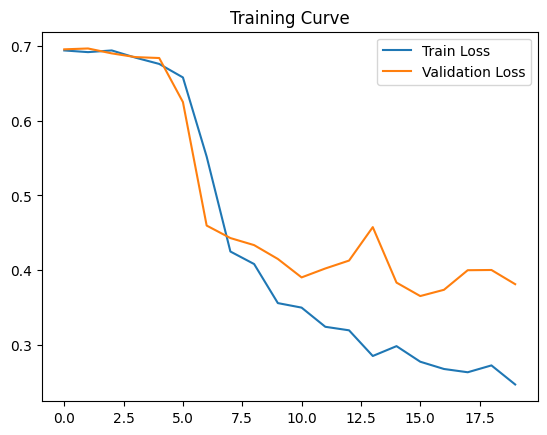

Validation ROC-AUC: 0.9200483091787439

Config: lr=0.0005, batch=16, hidden=64, layers=2
Epoch 1 | Train Loss: 0.6985 | Val Loss: 0.6964
Epoch 2 | Train Loss: 0.6902 | Val Loss: 0.6940
Epoch 3 | Train Loss: 0.6900 | Val Loss: 0.6934
Epoch 4 | Train Loss: 0.6889 | Val Loss: 0.6969
Epoch 5 | Train Loss: 0.6892 | Val Loss: 0.6938
Epoch 6 | Train Loss: 0.6891 | Val Loss: 0.6979
Epoch 7 | Train Loss: 0.6890 | Val Loss: 0.6926
Epoch 8 | Train Loss: 0.6869 | Val Loss: 0.6894
Epoch 9 | Train Loss: 0.6825 | Val Loss: 0.6730
Epoch 10 | Train Loss: 0.6267 | Val Loss: 0.5689
Epoch 11 | Train Loss: 0.5081 | Val Loss: 0.4848
Epoch 12 | Train Loss: 0.4769 | Val Loss: 0.4475
Epoch 13 | Train Loss: 0.3995 | Val Loss: 0.4992
Epoch 14 | Train Loss: 0.3883 | Val Loss: 0.4511
Epoch 15 | Train Loss: 0.3487 | Val Loss: 0.4682
Epoch 16 | Train Loss: 0.3435 | Val Loss: 0.4832
Epoch 17 | Train Loss: 0.3194 | Val Loss: 0.3900
Epoch 18 | Train Loss: 0.2974 | Val Loss: 0.3700
Epoch 19 | Train Loss: 0.2813 | Val Lo

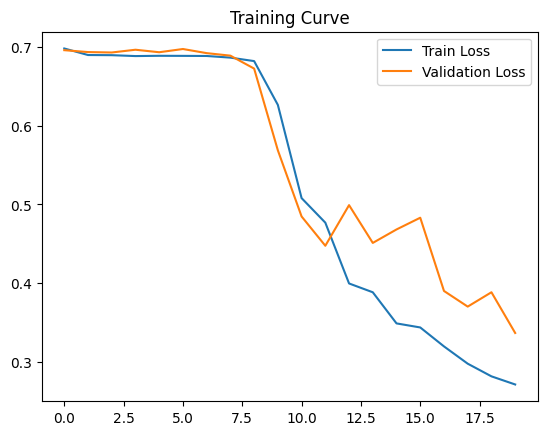

Validation ROC-AUC: 0.9349033816425121

Config: lr=0.0005, batch=16, hidden=128, layers=1


c:\Users\VARADHARAJAN K\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Epoch 1 | Train Loss: 0.7014 | Val Loss: 0.6978
Epoch 2 | Train Loss: 0.6948 | Val Loss: 0.6946
Epoch 3 | Train Loss: 0.6911 | Val Loss: 0.6933
Epoch 4 | Train Loss: 0.6918 | Val Loss: 0.6937
Epoch 5 | Train Loss: 0.6909 | Val Loss: 0.6929
Epoch 6 | Train Loss: 0.6916 | Val Loss: 0.6917
Epoch 7 | Train Loss: 0.6867 | Val Loss: 0.6952
Epoch 8 | Train Loss: 0.6816 | Val Loss: 0.6898
Epoch 9 | Train Loss: 0.6552 | Val Loss: 0.5935
Epoch 10 | Train Loss: 0.5707 | Val Loss: 0.5100
Epoch 11 | Train Loss: 0.5008 | Val Loss: 0.4570
Epoch 12 | Train Loss: 0.4075 | Val Loss: 0.4145
Epoch 13 | Train Loss: 0.3866 | Val Loss: 0.4118
Epoch 14 | Train Loss: 0.3579 | Val Loss: 0.4087
Epoch 15 | Train Loss: 0.3634 | Val Loss: 0.4077
Epoch 16 | Train Loss: 0.3298 | Val Loss: 0.3755
Epoch 17 | Train Loss: 0.2856 | Val Loss: 0.4207
Epoch 18 | Train Loss: 0.2708 | Val Loss: 0.3347
Epoch 19 | Train Loss: 0.2708 | Val Loss: 0.3161
Epoch 20 | Train Loss: 0.2460 | Val Loss: 0.3458


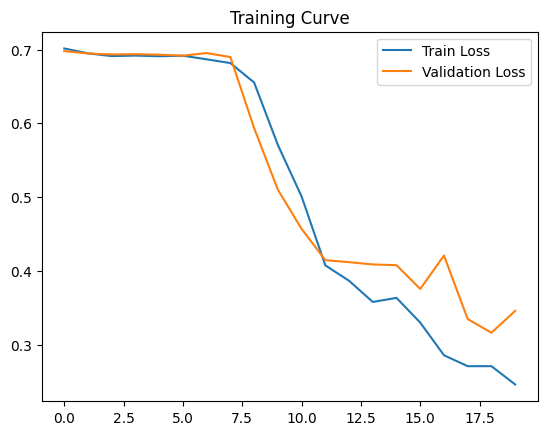

Validation ROC-AUC: 0.9350241545893719

Config: lr=0.0005, batch=16, hidden=128, layers=2
Epoch 1 | Train Loss: 0.6948 | Val Loss: 0.6926
Epoch 2 | Train Loss: 0.6933 | Val Loss: 0.6926
Epoch 3 | Train Loss: 0.6936 | Val Loss: 0.6922
Epoch 4 | Train Loss: 0.6898 | Val Loss: 0.7019
Epoch 5 | Train Loss: 0.6896 | Val Loss: 0.6932
Epoch 6 | Train Loss: 0.6890 | Val Loss: 0.6939
Early stopping triggered at epoch 6


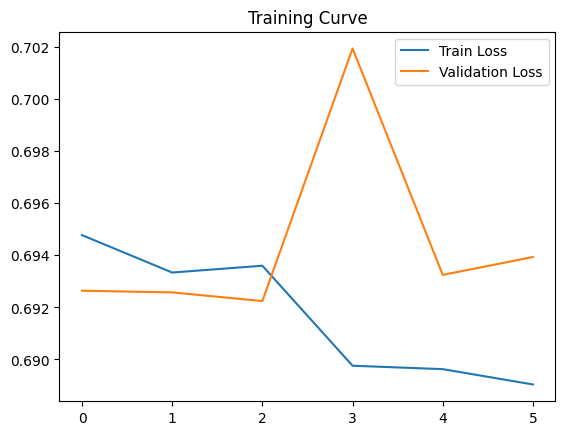

Validation ROC-AUC: 0.5340579710144928

Config: lr=0.0005, batch=32, hidden=64, layers=1


c:\Users\VARADHARAJAN K\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Epoch 1 | Train Loss: 0.6921 | Val Loss: 0.6939
Epoch 2 | Train Loss: 0.6919 | Val Loss: 0.6926
Epoch 3 | Train Loss: 0.6915 | Val Loss: 0.6933
Epoch 4 | Train Loss: 0.6895 | Val Loss: 0.6928
Epoch 5 | Train Loss: 0.6887 | Val Loss: 0.6939
Epoch 6 | Train Loss: 0.6869 | Val Loss: 0.6951
Epoch 7 | Train Loss: 0.6886 | Val Loss: 0.6929
Early stopping triggered at epoch 7


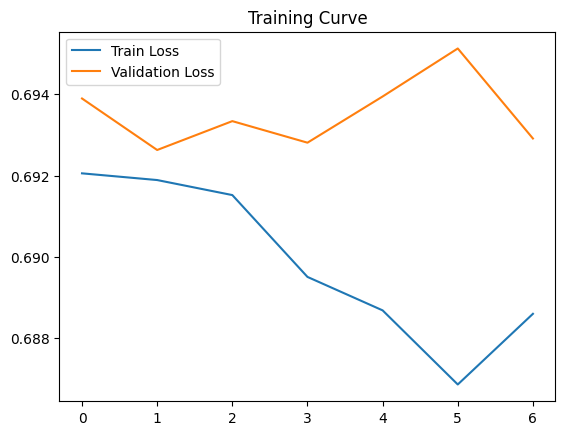

Validation ROC-AUC: 0.5227053140096618

Config: lr=0.0005, batch=32, hidden=64, layers=2
Epoch 1 | Train Loss: 0.6917 | Val Loss: 0.6952
Epoch 2 | Train Loss: 0.6881 | Val Loss: 0.7021
Epoch 3 | Train Loss: 0.6946 | Val Loss: 0.6935
Epoch 4 | Train Loss: 0.6922 | Val Loss: 0.6925
Epoch 5 | Train Loss: 0.6891 | Val Loss: 0.6928
Epoch 6 | Train Loss: 0.6922 | Val Loss: 0.6931
Epoch 7 | Train Loss: 0.6911 | Val Loss: 0.6926
Epoch 8 | Train Loss: 0.6912 | Val Loss: 0.6968
Early stopping triggered at epoch 8


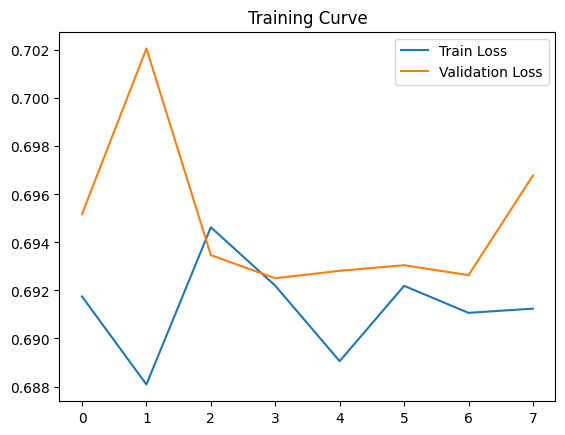

Validation ROC-AUC: 0.5392512077294687

Config: lr=0.0005, batch=32, hidden=128, layers=1


c:\Users\VARADHARAJAN K\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Epoch 1 | Train Loss: 0.6944 | Val Loss: 0.6927
Epoch 2 | Train Loss: 0.6950 | Val Loss: 0.6963
Epoch 3 | Train Loss: 0.6961 | Val Loss: 0.6938
Epoch 4 | Train Loss: 0.6908 | Val Loss: 0.6922
Epoch 5 | Train Loss: 0.6882 | Val Loss: 0.6925
Epoch 6 | Train Loss: 0.6872 | Val Loss: 0.6994
Early stopping triggered at epoch 6


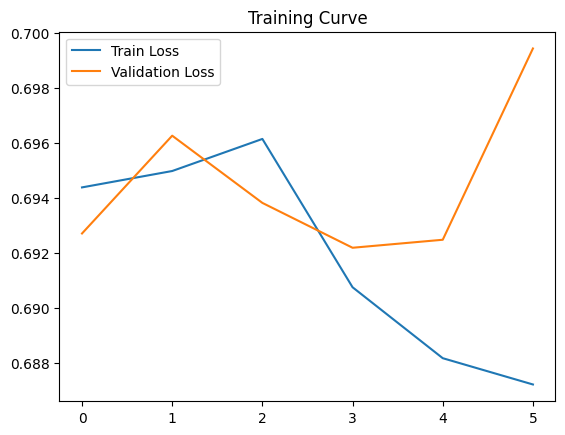

Validation ROC-AUC: 0.5312801932367149

Config: lr=0.0005, batch=32, hidden=128, layers=2
Epoch 1 | Train Loss: 0.6952 | Val Loss: 0.6974
Epoch 2 | Train Loss: 0.6951 | Val Loss: 0.6931
Epoch 3 | Train Loss: 0.6902 | Val Loss: 0.6925
Epoch 4 | Train Loss: 0.6897 | Val Loss: 0.6921
Epoch 5 | Train Loss: 0.6911 | Val Loss: 0.6915
Epoch 6 | Train Loss: 0.6889 | Val Loss: 0.6907
Epoch 7 | Train Loss: 0.6891 | Val Loss: 0.6918
Epoch 8 | Train Loss: 0.6887 | Val Loss: 0.6878
Epoch 9 | Train Loss: 0.6851 | Val Loss: 0.6852
Epoch 10 | Train Loss: 0.6646 | Val Loss: 0.6181
Epoch 11 | Train Loss: 0.5907 | Val Loss: 0.4893
Epoch 12 | Train Loss: 0.4991 | Val Loss: 0.4390
Epoch 13 | Train Loss: 0.4259 | Val Loss: 0.4614
Epoch 14 | Train Loss: 0.4698 | Val Loss: 0.4092
Epoch 15 | Train Loss: 0.3892 | Val Loss: 0.4253
Epoch 16 | Train Loss: 0.3882 | Val Loss: 0.4232
Epoch 17 | Train Loss: 0.3372 | Val Loss: 0.4189
Epoch 18 | Train Loss: 0.3168 | Val Loss: 0.3651
Epoch 19 | Train Loss: 0.2948 | Val L

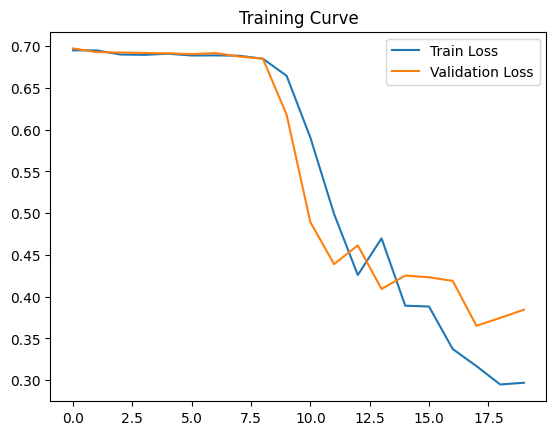

Validation ROC-AUC: 0.9134057971014493

Best config for GRU: {'lr': 0.001, 'batch_size': 16, 'hidden_size': 64, 'layers': 2}
Best validation AUC: 0.9502

===== Tuning AttentionLSTM =====

Config: lr=0.001, batch=16, hidden=64, layers=1
Epoch 1 | Train Loss: 0.6747 | Val Loss: 0.5935
Epoch 2 | Train Loss: 0.6321 | Val Loss: 0.5511
Epoch 3 | Train Loss: 0.5147 | Val Loss: 0.4986
Epoch 4 | Train Loss: 0.4806 | Val Loss: 0.4891
Epoch 5 | Train Loss: 0.4585 | Val Loss: 0.4817
Epoch 6 | Train Loss: 0.4177 | Val Loss: 0.4593
Epoch 7 | Train Loss: 0.3844 | Val Loss: 0.4684
Epoch 8 | Train Loss: 0.3689 | Val Loss: 0.4990
Epoch 9 | Train Loss: 0.3676 | Val Loss: 0.4610
Epoch 10 | Train Loss: 0.3528 | Val Loss: 0.4477
Epoch 11 | Train Loss: 0.3635 | Val Loss: 0.4846
Epoch 12 | Train Loss: 0.3337 | Val Loss: 0.4381
Epoch 13 | Train Loss: 0.3263 | Val Loss: 0.5438
Epoch 14 | Train Loss: 0.3493 | Val Loss: 0.4450
Epoch 15 | Train Loss: 0.3132 | Val Loss: 0.4449
Epoch 16 | Train Loss: 0.3142 | Val Lo

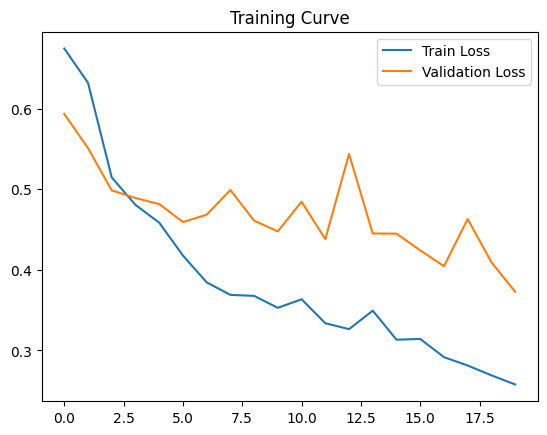

Validation ROC-AUC: 0.9154589371980677

Config: lr=0.001, batch=16, hidden=64, layers=2
Epoch 1 | Train Loss: 0.6663 | Val Loss: 0.5488
Epoch 2 | Train Loss: 0.5194 | Val Loss: 0.4778
Epoch 3 | Train Loss: 0.4391 | Val Loss: 0.4695
Epoch 4 | Train Loss: 0.4276 | Val Loss: 0.4365
Epoch 5 | Train Loss: 0.3832 | Val Loss: 0.4671
Epoch 6 | Train Loss: 0.3611 | Val Loss: 0.4319
Epoch 7 | Train Loss: 0.3406 | Val Loss: 0.4521
Epoch 8 | Train Loss: 0.3517 | Val Loss: 0.4163
Epoch 9 | Train Loss: 0.3599 | Val Loss: 0.4042
Epoch 10 | Train Loss: 0.3440 | Val Loss: 0.4160
Epoch 11 | Train Loss: 0.3227 | Val Loss: 0.3858
Epoch 12 | Train Loss: 0.3113 | Val Loss: 0.3984
Epoch 13 | Train Loss: 0.3052 | Val Loss: 0.3678
Epoch 14 | Train Loss: 0.2757 | Val Loss: 0.3868
Epoch 15 | Train Loss: 0.2837 | Val Loss: 0.3802
Epoch 16 | Train Loss: 0.2698 | Val Loss: 0.3349
Epoch 17 | Train Loss: 0.2668 | Val Loss: 0.3550
Epoch 18 | Train Loss: 0.2467 | Val Loss: 0.3292
Epoch 19 | Train Loss: 0.2580 | Val Los

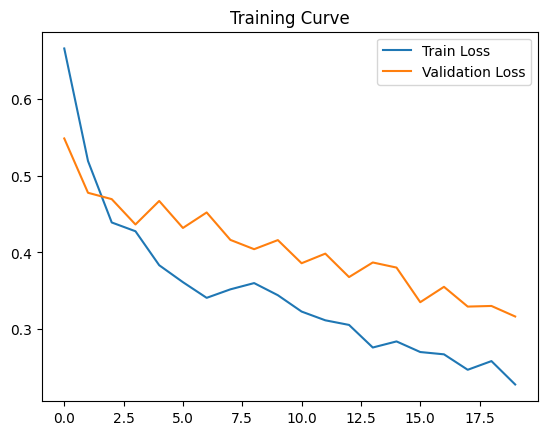

Validation ROC-AUC: 0.9342995169082126

Config: lr=0.001, batch=16, hidden=128, layers=1
Epoch 1 | Train Loss: 0.6672 | Val Loss: 0.5576
Epoch 2 | Train Loss: 0.5506 | Val Loss: 0.5370
Epoch 3 | Train Loss: 0.4802 | Val Loss: 0.4999
Epoch 4 | Train Loss: 0.4277 | Val Loss: 0.4725
Epoch 5 | Train Loss: 0.3840 | Val Loss: 0.4577
Epoch 6 | Train Loss: 0.3749 | Val Loss: 0.4862
Epoch 7 | Train Loss: 0.3775 | Val Loss: 0.4391
Epoch 8 | Train Loss: 0.3491 | Val Loss: 0.4282
Epoch 9 | Train Loss: 0.3432 | Val Loss: 0.4543
Epoch 10 | Train Loss: 0.3400 | Val Loss: 0.4368
Epoch 11 | Train Loss: 0.3207 | Val Loss: 0.3585
Epoch 12 | Train Loss: 0.3095 | Val Loss: 0.3568
Epoch 13 | Train Loss: 0.2946 | Val Loss: 0.4565
Epoch 14 | Train Loss: 0.2982 | Val Loss: 0.3911
Epoch 15 | Train Loss: 0.2673 | Val Loss: 0.3731
Epoch 16 | Train Loss: 0.2699 | Val Loss: 0.3327
Epoch 17 | Train Loss: 0.2696 | Val Loss: 0.3453
Epoch 18 | Train Loss: 0.2201 | Val Loss: 0.3272
Epoch 19 | Train Loss: 0.2081 | Val Lo

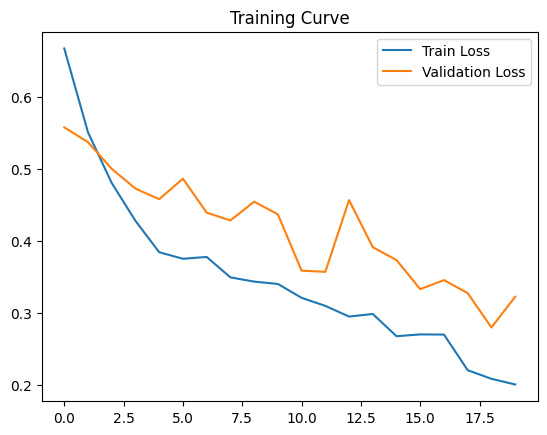

Validation ROC-AUC: 0.9428743961352659

Config: lr=0.001, batch=16, hidden=128, layers=2
Epoch 1 | Train Loss: 0.6953 | Val Loss: 0.6530
Epoch 2 | Train Loss: 0.5618 | Val Loss: 0.4979
Epoch 3 | Train Loss: 0.4708 | Val Loss: 0.4806
Epoch 4 | Train Loss: 0.4346 | Val Loss: 0.4728
Epoch 5 | Train Loss: 0.4010 | Val Loss: 0.5146
Epoch 6 | Train Loss: 0.4005 | Val Loss: 0.4765
Epoch 7 | Train Loss: 0.3590 | Val Loss: 0.5406
Epoch 8 | Train Loss: 0.3650 | Val Loss: 0.4291
Epoch 9 | Train Loss: 0.3361 | Val Loss: 0.4523
Epoch 10 | Train Loss: 0.3370 | Val Loss: 0.3930
Epoch 11 | Train Loss: 0.2982 | Val Loss: 0.3922
Epoch 12 | Train Loss: 0.2969 | Val Loss: 0.4032
Epoch 13 | Train Loss: 0.2658 | Val Loss: 0.4007
Epoch 14 | Train Loss: 0.2636 | Val Loss: 0.3659
Epoch 15 | Train Loss: 0.2390 | Val Loss: 0.3724
Epoch 16 | Train Loss: 0.2313 | Val Loss: 0.4031
Epoch 17 | Train Loss: 0.2522 | Val Loss: 0.3365
Epoch 18 | Train Loss: 0.2042 | Val Loss: 0.3980
Epoch 19 | Train Loss: 0.2013 | Val Lo

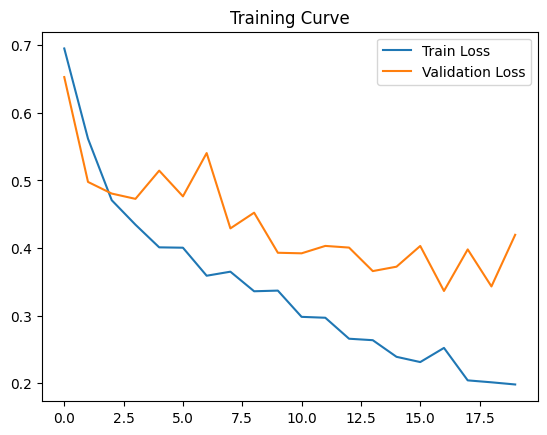

Validation ROC-AUC: 0.9371980676328503

Config: lr=0.001, batch=32, hidden=64, layers=1
Epoch 1 | Train Loss: 0.6967 | Val Loss: 0.6786
Epoch 2 | Train Loss: 0.6541 | Val Loss: 0.6216
Epoch 3 | Train Loss: 0.5549 | Val Loss: 0.5037
Epoch 4 | Train Loss: 0.5022 | Val Loss: 0.4804
Epoch 5 | Train Loss: 0.4277 | Val Loss: 0.4536
Epoch 6 | Train Loss: 0.4046 | Val Loss: 0.4488
Epoch 7 | Train Loss: 0.3757 | Val Loss: 0.4258
Epoch 8 | Train Loss: 0.3525 | Val Loss: 0.4205
Epoch 9 | Train Loss: 0.3553 | Val Loss: 0.4464
Epoch 10 | Train Loss: 0.3867 | Val Loss: 0.4713
Epoch 11 | Train Loss: 0.3454 | Val Loss: 0.4090
Epoch 12 | Train Loss: 0.3373 | Val Loss: 0.4180
Epoch 13 | Train Loss: 0.3287 | Val Loss: 0.3942
Epoch 14 | Train Loss: 0.3213 | Val Loss: 0.3966
Epoch 15 | Train Loss: 0.3100 | Val Loss: 0.3904
Epoch 16 | Train Loss: 0.3208 | Val Loss: 0.4470
Epoch 17 | Train Loss: 0.3129 | Val Loss: 0.3735
Epoch 18 | Train Loss: 0.2831 | Val Loss: 0.3940
Epoch 19 | Train Loss: 0.2786 | Val Los

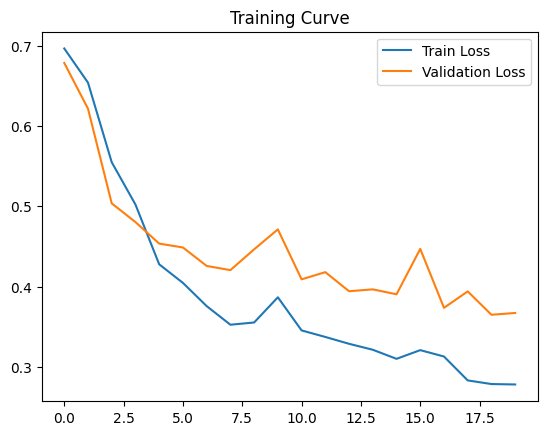

Validation ROC-AUC: 0.917512077294686

Config: lr=0.001, batch=32, hidden=64, layers=2
Epoch 1 | Train Loss: 0.6837 | Val Loss: 0.6477
Epoch 2 | Train Loss: 0.5738 | Val Loss: 0.5223
Epoch 3 | Train Loss: 0.5024 | Val Loss: 0.5294
Epoch 4 | Train Loss: 0.4645 | Val Loss: 0.4571
Epoch 5 | Train Loss: 0.4072 | Val Loss: 0.4884
Epoch 6 | Train Loss: 0.3864 | Val Loss: 0.4619
Epoch 7 | Train Loss: 0.3728 | Val Loss: 0.4606
Epoch 8 | Train Loss: 0.3681 | Val Loss: 0.4323
Epoch 9 | Train Loss: 0.3768 | Val Loss: 0.4187
Epoch 10 | Train Loss: 0.3474 | Val Loss: 0.4272
Epoch 11 | Train Loss: 0.3346 | Val Loss: 0.5127
Epoch 12 | Train Loss: 0.3199 | Val Loss: 0.4082
Epoch 13 | Train Loss: 0.3373 | Val Loss: 0.4314
Epoch 14 | Train Loss: 0.3005 | Val Loss: 0.4339
Epoch 15 | Train Loss: 0.2891 | Val Loss: 0.4443
Epoch 16 | Train Loss: 0.3615 | Val Loss: 0.4265
Epoch 17 | Train Loss: 0.3050 | Val Loss: 0.4197
Early stopping triggered at epoch 17


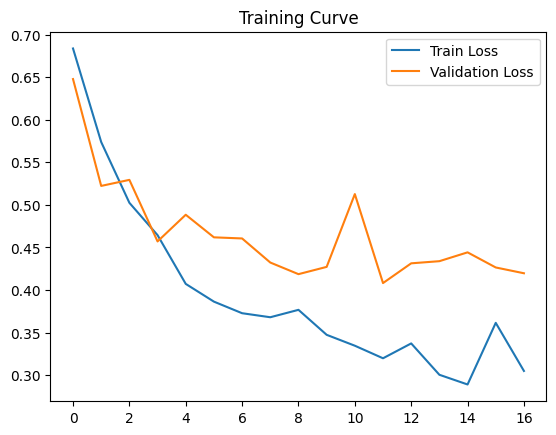

Validation ROC-AUC: 0.8981884057971015

Config: lr=0.001, batch=32, hidden=128, layers=1
Epoch 1 | Train Loss: 0.6931 | Val Loss: 0.6682
Epoch 2 | Train Loss: 0.5948 | Val Loss: 0.5527
Epoch 3 | Train Loss: 0.5200 | Val Loss: 0.5154
Epoch 4 | Train Loss: 0.4929 | Val Loss: 0.4888
Epoch 5 | Train Loss: 0.4458 | Val Loss: 0.4477
Epoch 6 | Train Loss: 0.4093 | Val Loss: 0.4547
Epoch 7 | Train Loss: 0.4071 | Val Loss: 0.4387
Epoch 8 | Train Loss: 0.3659 | Val Loss: 0.4467
Epoch 9 | Train Loss: 0.3550 | Val Loss: 0.4314
Epoch 10 | Train Loss: 0.3518 | Val Loss: 0.4095
Epoch 11 | Train Loss: 0.3318 | Val Loss: 0.4000
Epoch 12 | Train Loss: 0.3266 | Val Loss: 0.3946
Epoch 13 | Train Loss: 0.3221 | Val Loss: 0.3977
Epoch 14 | Train Loss: 0.3118 | Val Loss: 0.4383
Epoch 15 | Train Loss: 0.3419 | Val Loss: 0.4177
Epoch 16 | Train Loss: 0.3007 | Val Loss: 0.3881
Epoch 17 | Train Loss: 0.3071 | Val Loss: 0.4180
Epoch 18 | Train Loss: 0.2702 | Val Loss: 0.3769
Epoch 19 | Train Loss: 0.2560 | Val Lo

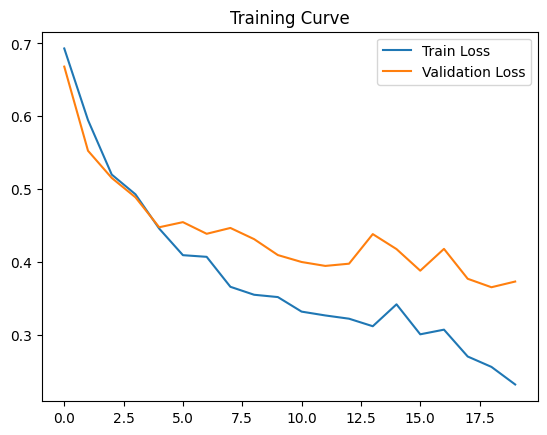

Validation ROC-AUC: 0.9271739130434782

Config: lr=0.001, batch=32, hidden=128, layers=2
Epoch 1 | Train Loss: 0.6911 | Val Loss: 0.6686
Epoch 2 | Train Loss: 0.5884 | Val Loss: 0.5676
Epoch 3 | Train Loss: 0.5285 | Val Loss: 0.5052
Epoch 4 | Train Loss: 0.4801 | Val Loss: 0.4749
Epoch 5 | Train Loss: 0.4364 | Val Loss: 0.4862
Epoch 6 | Train Loss: 0.4104 | Val Loss: 0.4519
Epoch 7 | Train Loss: 0.4128 | Val Loss: 0.4340
Epoch 8 | Train Loss: 0.3707 | Val Loss: 0.4448
Epoch 9 | Train Loss: 0.3510 | Val Loss: 0.4108
Epoch 10 | Train Loss: 0.3642 | Val Loss: 0.4119
Epoch 11 | Train Loss: 0.3411 | Val Loss: 0.4081
Epoch 12 | Train Loss: 0.3581 | Val Loss: 0.3788
Epoch 13 | Train Loss: 0.3382 | Val Loss: 0.3989
Epoch 14 | Train Loss: 0.3166 | Val Loss: 0.3999
Epoch 15 | Train Loss: 0.3130 | Val Loss: 0.3949
Epoch 16 | Train Loss: 0.3264 | Val Loss: 0.3401
Epoch 17 | Train Loss: 0.2889 | Val Loss: 0.3956
Epoch 18 | Train Loss: 0.2790 | Val Loss: 0.3785
Epoch 19 | Train Loss: 0.2941 | Val Lo

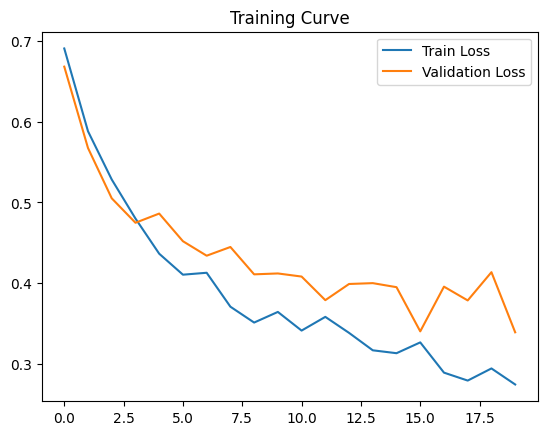

Validation ROC-AUC: 0.927415458937198

Config: lr=0.0005, batch=16, hidden=64, layers=1
Epoch 1 | Train Loss: 0.6848 | Val Loss: 0.6609
Epoch 2 | Train Loss: 0.6184 | Val Loss: 0.5844
Epoch 3 | Train Loss: 0.5154 | Val Loss: 0.4773
Epoch 4 | Train Loss: 0.4564 | Val Loss: 0.4459
Epoch 5 | Train Loss: 0.4131 | Val Loss: 0.6050
Epoch 6 | Train Loss: 0.4235 | Val Loss: 0.5011
Epoch 7 | Train Loss: 0.3765 | Val Loss: 0.4338
Epoch 8 | Train Loss: 0.3648 | Val Loss: 0.4505
Epoch 9 | Train Loss: 0.3568 | Val Loss: 0.4308
Epoch 10 | Train Loss: 0.3306 | Val Loss: 0.4223
Epoch 11 | Train Loss: 0.3477 | Val Loss: 0.4288
Epoch 12 | Train Loss: 0.3153 | Val Loss: 0.4585
Epoch 13 | Train Loss: 0.3004 | Val Loss: 0.4846
Epoch 14 | Train Loss: 0.2880 | Val Loss: 0.3691
Epoch 15 | Train Loss: 0.2726 | Val Loss: 0.3678
Epoch 16 | Train Loss: 0.2755 | Val Loss: 0.3807
Epoch 17 | Train Loss: 0.2503 | Val Loss: 0.5401
Epoch 18 | Train Loss: 0.3044 | Val Loss: 0.3703
Epoch 19 | Train Loss: 0.2522 | Val Los

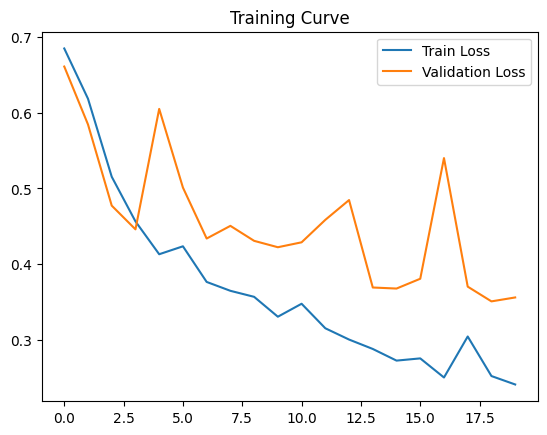

Validation ROC-AUC: 0.9108695652173914

Config: lr=0.0005, batch=16, hidden=64, layers=2
Epoch 1 | Train Loss: 0.6887 | Val Loss: 0.6698
Epoch 2 | Train Loss: 0.6025 | Val Loss: 0.5290
Epoch 3 | Train Loss: 0.5114 | Val Loss: 0.5116
Epoch 4 | Train Loss: 0.4621 | Val Loss: 0.5054
Epoch 5 | Train Loss: 0.4020 | Val Loss: 0.4621
Epoch 6 | Train Loss: 0.3991 | Val Loss: 0.4953
Epoch 7 | Train Loss: 0.3809 | Val Loss: 0.4733
Epoch 8 | Train Loss: 0.4213 | Val Loss: 0.4589
Epoch 9 | Train Loss: 0.3681 | Val Loss: 0.4558
Epoch 10 | Train Loss: 0.3289 | Val Loss: 0.4846
Epoch 11 | Train Loss: 0.3288 | Val Loss: 0.4687
Epoch 12 | Train Loss: 0.3142 | Val Loss: 0.4750
Epoch 13 | Train Loss: 0.3108 | Val Loss: 0.4852
Epoch 14 | Train Loss: 0.3121 | Val Loss: 0.5969
Early stopping triggered at epoch 14


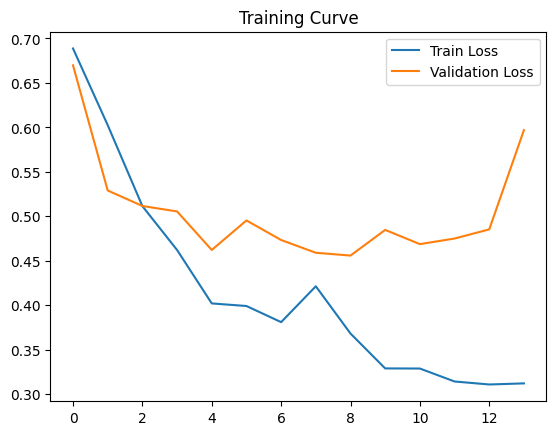

Validation ROC-AUC: 0.8719806763285024

Config: lr=0.0005, batch=16, hidden=128, layers=1
Epoch 1 | Train Loss: 0.6793 | Val Loss: 0.6099
Epoch 2 | Train Loss: 0.5809 | Val Loss: 0.5172
Epoch 3 | Train Loss: 0.4991 | Val Loss: 0.4897
Epoch 4 | Train Loss: 0.4623 | Val Loss: 0.5161
Epoch 5 | Train Loss: 0.4472 | Val Loss: 0.4575
Epoch 6 | Train Loss: 0.4176 | Val Loss: 0.4510
Epoch 7 | Train Loss: 0.3760 | Val Loss: 0.4578
Epoch 8 | Train Loss: 0.4025 | Val Loss: 0.4491
Epoch 9 | Train Loss: 0.3896 | Val Loss: 0.4477
Epoch 10 | Train Loss: 0.3638 | Val Loss: 0.5045
Epoch 11 | Train Loss: 0.3445 | Val Loss: 0.4473
Epoch 12 | Train Loss: 0.3435 | Val Loss: 0.4283
Epoch 13 | Train Loss: 0.3301 | Val Loss: 0.4281
Epoch 14 | Train Loss: 0.3254 | Val Loss: 0.4180
Epoch 15 | Train Loss: 0.2982 | Val Loss: 0.4265
Epoch 16 | Train Loss: 0.3195 | Val Loss: 0.4366
Epoch 17 | Train Loss: 0.2936 | Val Loss: 0.3904
Epoch 18 | Train Loss: 0.2759 | Val Loss: 0.5733
Epoch 19 | Train Loss: 0.2981 | Val L

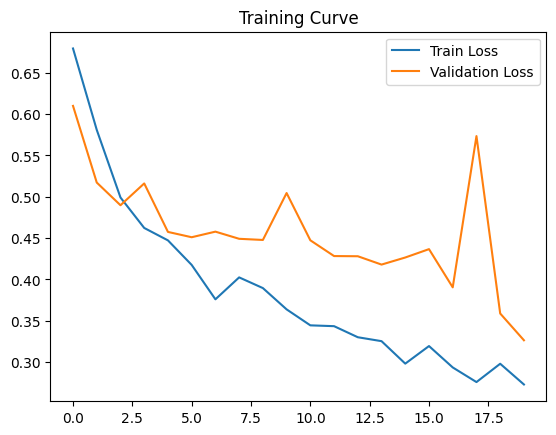

Validation ROC-AUC: 0.9322463768115942

Config: lr=0.0005, batch=16, hidden=128, layers=2
Epoch 1 | Train Loss: 0.6896 | Val Loss: 0.6498
Epoch 2 | Train Loss: 0.5897 | Val Loss: 0.4925
Epoch 3 | Train Loss: 0.4918 | Val Loss: 0.4778
Epoch 4 | Train Loss: 0.4663 | Val Loss: 0.4736
Epoch 5 | Train Loss: 0.4224 | Val Loss: 0.4816
Epoch 6 | Train Loss: 0.4224 | Val Loss: 0.4607
Epoch 7 | Train Loss: 0.3995 | Val Loss: 0.4743
Epoch 8 | Train Loss: 0.3964 | Val Loss: 0.4777
Epoch 9 | Train Loss: 0.3705 | Val Loss: 0.4656
Epoch 10 | Train Loss: 0.3597 | Val Loss: 0.4312
Epoch 11 | Train Loss: 0.3565 | Val Loss: 0.4303
Epoch 12 | Train Loss: 0.3368 | Val Loss: 0.4225
Epoch 13 | Train Loss: 0.3367 | Val Loss: 0.4320
Epoch 14 | Train Loss: 0.3254 | Val Loss: 0.4011
Epoch 15 | Train Loss: 0.3062 | Val Loss: 0.4001
Epoch 16 | Train Loss: 0.2921 | Val Loss: 0.3574
Epoch 17 | Train Loss: 0.2807 | Val Loss: 0.3799
Epoch 18 | Train Loss: 0.2630 | Val Loss: 0.3350
Epoch 19 | Train Loss: 0.2632 | Val L

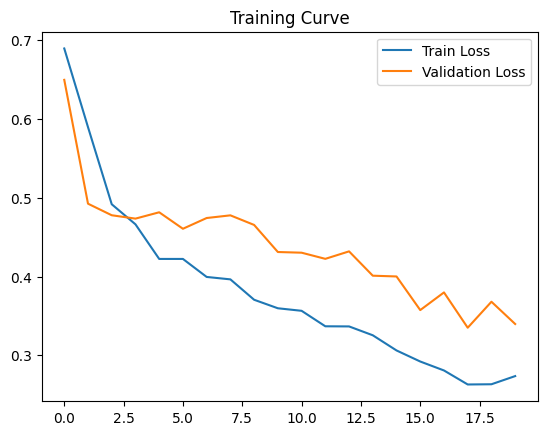

Validation ROC-AUC: 0.9285024154589372

Config: lr=0.0005, batch=32, hidden=64, layers=1
Epoch 1 | Train Loss: 0.6934 | Val Loss: 0.6830
Epoch 2 | Train Loss: 0.6709 | Val Loss: 0.6407
Epoch 3 | Train Loss: 0.5937 | Val Loss: 0.5698
Epoch 4 | Train Loss: 0.5203 | Val Loss: 0.4893
Epoch 5 | Train Loss: 0.5053 | Val Loss: 0.4927
Epoch 6 | Train Loss: 0.4642 | Val Loss: 0.4546
Epoch 7 | Train Loss: 0.4218 | Val Loss: 0.4391
Epoch 8 | Train Loss: 0.4067 | Val Loss: 0.4476
Epoch 9 | Train Loss: 0.4003 | Val Loss: 0.4402
Epoch 10 | Train Loss: 0.3765 | Val Loss: 0.4369
Epoch 11 | Train Loss: 0.3528 | Val Loss: 0.4490
Epoch 12 | Train Loss: 0.3490 | Val Loss: 0.4378
Epoch 13 | Train Loss: 0.3318 | Val Loss: 0.4251
Epoch 14 | Train Loss: 0.3321 | Val Loss: 0.4247
Epoch 15 | Train Loss: 0.3213 | Val Loss: 0.4435
Epoch 16 | Train Loss: 0.3210 | Val Loss: 0.4962
Epoch 17 | Train Loss: 0.3213 | Val Loss: 0.4344
Epoch 18 | Train Loss: 0.2924 | Val Loss: 0.4387
Early stopping triggered at epoch 18


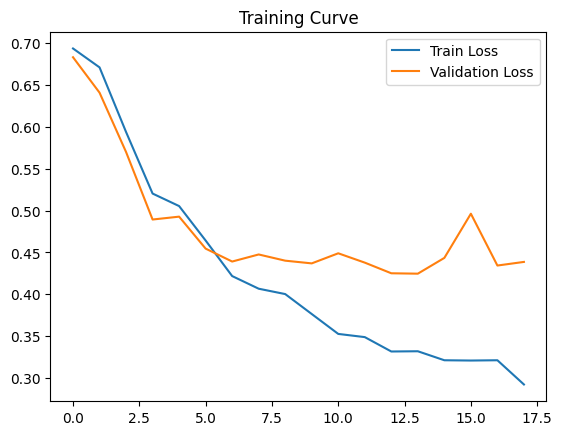

Validation ROC-AUC: 0.8871980676328503

Config: lr=0.0005, batch=32, hidden=64, layers=2
Epoch 1 | Train Loss: 0.6936 | Val Loss: 0.6849
Epoch 2 | Train Loss: 0.6751 | Val Loss: 0.6532
Epoch 3 | Train Loss: 0.6030 | Val Loss: 0.5637
Epoch 4 | Train Loss: 0.5505 | Val Loss: 0.5046
Epoch 5 | Train Loss: 0.5301 | Val Loss: 0.5082
Epoch 6 | Train Loss: 0.4871 | Val Loss: 0.4959
Epoch 7 | Train Loss: 0.4587 | Val Loss: 0.4815
Epoch 8 | Train Loss: 0.4489 | Val Loss: 0.4660
Epoch 9 | Train Loss: 0.4057 | Val Loss: 0.4943
Epoch 10 | Train Loss: 0.3947 | Val Loss: 0.4457
Epoch 11 | Train Loss: 0.3640 | Val Loss: 0.4515
Epoch 12 | Train Loss: 0.3519 | Val Loss: 0.4824
Epoch 13 | Train Loss: 0.3656 | Val Loss: 0.4827
Epoch 14 | Train Loss: 0.3515 | Val Loss: 0.4244
Epoch 15 | Train Loss: 0.3465 | Val Loss: 0.4249
Epoch 16 | Train Loss: 0.3385 | Val Loss: 0.4216
Epoch 17 | Train Loss: 0.3026 | Val Loss: 0.4411
Epoch 18 | Train Loss: 0.3290 | Val Loss: 0.4721
Epoch 19 | Train Loss: 0.3214 | Val Lo

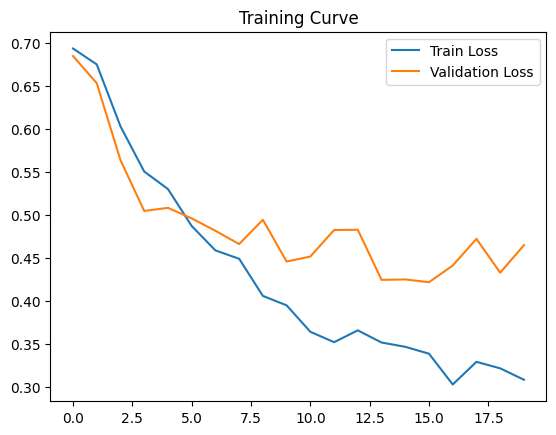

Validation ROC-AUC: 0.8911835748792271

Config: lr=0.0005, batch=32, hidden=128, layers=1
Epoch 1 | Train Loss: 0.7008 | Val Loss: 0.6937
Epoch 2 | Train Loss: 0.6840 | Val Loss: 0.6642
Epoch 3 | Train Loss: 0.5883 | Val Loss: 0.5183
Epoch 4 | Train Loss: 0.5021 | Val Loss: 0.4840
Epoch 5 | Train Loss: 0.4840 | Val Loss: 0.4868
Epoch 6 | Train Loss: 0.4504 | Val Loss: 0.4768
Epoch 7 | Train Loss: 0.4177 | Val Loss: 0.4428
Epoch 8 | Train Loss: 0.3914 | Val Loss: 0.4586
Epoch 9 | Train Loss: 0.3729 | Val Loss: 0.4353
Epoch 10 | Train Loss: 0.3591 | Val Loss: 0.4232
Epoch 11 | Train Loss: 0.3601 | Val Loss: 0.4312
Epoch 12 | Train Loss: 0.3468 | Val Loss: 0.4446
Epoch 13 | Train Loss: 0.3328 | Val Loss: 0.4520
Epoch 14 | Train Loss: 0.3450 | Val Loss: 0.4495
Epoch 15 | Train Loss: 0.3019 | Val Loss: 0.4492
Early stopping triggered at epoch 15


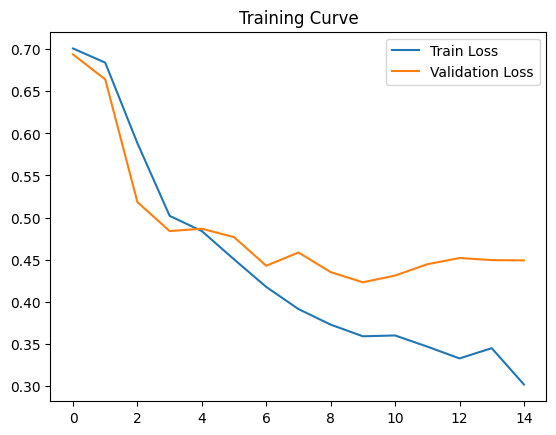

Validation ROC-AUC: 0.8940821256038648

Config: lr=0.0005, batch=32, hidden=128, layers=2
Epoch 1 | Train Loss: 0.6906 | Val Loss: 0.6844
Epoch 2 | Train Loss: 0.6584 | Val Loss: 0.5874
Epoch 3 | Train Loss: 0.5805 | Val Loss: 0.5040
Epoch 4 | Train Loss: 0.5241 | Val Loss: 0.5493
Epoch 5 | Train Loss: 0.5009 | Val Loss: 0.4755
Epoch 6 | Train Loss: 0.4532 | Val Loss: 0.4917
Epoch 7 | Train Loss: 0.4152 | Val Loss: 0.4813
Epoch 8 | Train Loss: 0.4456 | Val Loss: 0.4948
Epoch 9 | Train Loss: 0.3973 | Val Loss: 0.4510
Epoch 10 | Train Loss: 0.3724 | Val Loss: 0.4458
Epoch 11 | Train Loss: 0.4078 | Val Loss: 0.4650
Epoch 12 | Train Loss: 0.3679 | Val Loss: 0.4607
Epoch 13 | Train Loss: 0.3569 | Val Loss: 0.4737
Epoch 14 | Train Loss: 0.3565 | Val Loss: 0.4490
Epoch 15 | Train Loss: 0.3265 | Val Loss: 0.4504
Early stopping triggered at epoch 15


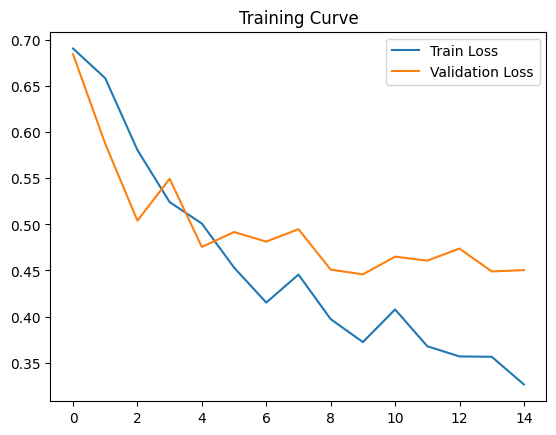

Validation ROC-AUC: 0.8800724637681159

Best config for AttentionLSTM: {'lr': 0.001, 'batch_size': 16, 'hidden_size': 128, 'layers': 1}
Best validation AUC: 0.9429

===== Tuning ResNet18 =====

Config: lr=0.0005, batch=16


c:\Users\VARADHARAJAN K\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\VARADHARAJAN K\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1 | Train Loss: 0.6504 | Val Loss: 1.5425
Epoch 2 | Train Loss: 0.3176 | Val Loss: 0.4183
Epoch 3 | Train Loss: 0.1650 | Val Loss: 0.5541
Epoch 4 | Train Loss: 0.1192 | Val Loss: 0.5373
Epoch 5 | Train Loss: 0.0838 | Val Loss: 1.3178
Epoch 6 | Train Loss: 0.0914 | Val Loss: 0.7078
Epoch 7 | Train Loss: 0.0803 | Val Loss: 0.5861
Early stopping triggered at epoch 7


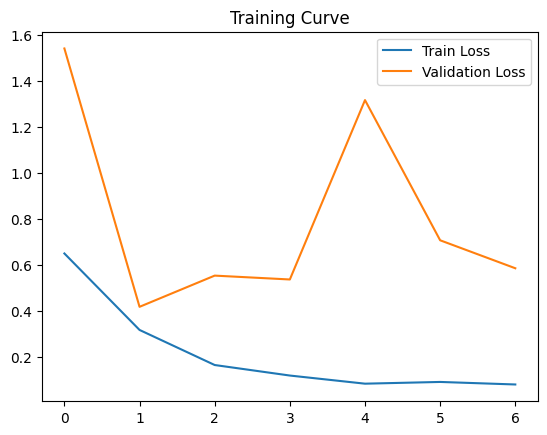

Validation ROC-AUC: 0.9294685990338164

Config: lr=0.0005, batch=32


c:\Users\VARADHARAJAN K\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\VARADHARAJAN K\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1 | Train Loss: 0.5323 | Val Loss: 0.4589
Epoch 2 | Train Loss: 0.2659 | Val Loss: 0.8968
Epoch 3 | Train Loss: 0.1889 | Val Loss: 0.3290
Epoch 4 | Train Loss: 0.0544 | Val Loss: 0.3879
Epoch 5 | Train Loss: 0.0325 | Val Loss: 0.4729
Epoch 6 | Train Loss: 0.0356 | Val Loss: 0.5561
Epoch 7 | Train Loss: 0.0271 | Val Loss: 0.4189
Epoch 8 | Train Loss: 0.0712 | Val Loss: 0.4596
Early stopping triggered at epoch 8


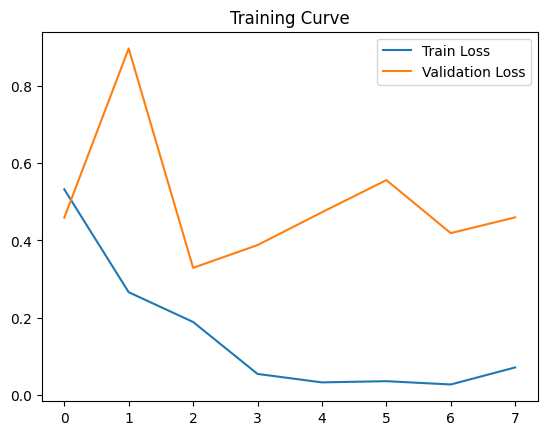

Validation ROC-AUC: 0.9628019323671497

Config: lr=0.0001, batch=16


c:\Users\VARADHARAJAN K\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\VARADHARAJAN K\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1 | Train Loss: 0.5415 | Val Loss: 0.4758
Epoch 2 | Train Loss: 0.1999 | Val Loss: 0.4490
Epoch 3 | Train Loss: 0.0928 | Val Loss: 0.5739
Epoch 4 | Train Loss: 0.0362 | Val Loss: 0.4957
Epoch 5 | Train Loss: 0.0318 | Val Loss: 0.6005
Epoch 6 | Train Loss: 0.0168 | Val Loss: 0.5616
Epoch 7 | Train Loss: 0.0183 | Val Loss: 0.5819
Early stopping triggered at epoch 7


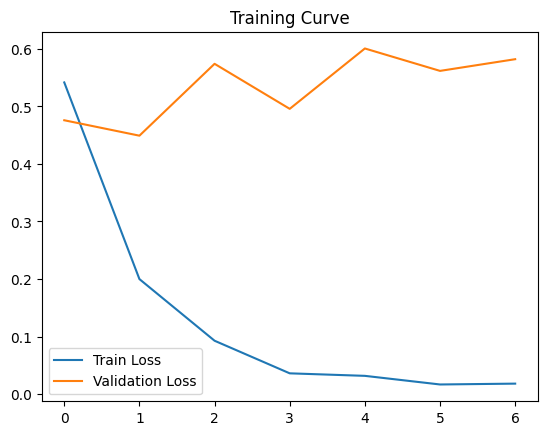

Validation ROC-AUC: 0.9295893719806763

Config: lr=0.0001, batch=32


c:\Users\VARADHARAJAN K\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\VARADHARAJAN K\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1 | Train Loss: 0.5908 | Val Loss: 0.6225
Epoch 2 | Train Loss: 0.1731 | Val Loss: 0.5379
Epoch 3 | Train Loss: 0.0603 | Val Loss: 0.5479
Epoch 4 | Train Loss: 0.0206 | Val Loss: 0.6394
Epoch 5 | Train Loss: 0.0151 | Val Loss: 0.6109
Epoch 6 | Train Loss: 0.0087 | Val Loss: 0.6556
Epoch 7 | Train Loss: 0.0042 | Val Loss: 0.6443
Early stopping triggered at epoch 7


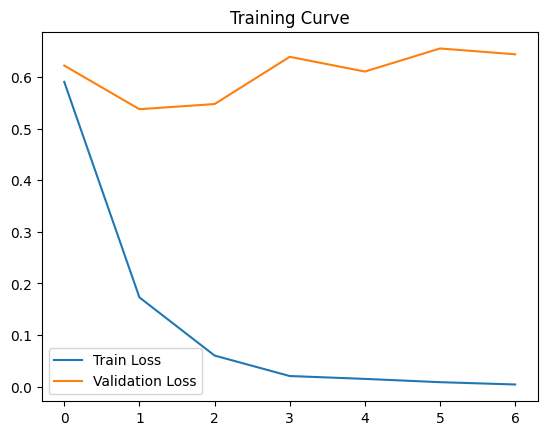

Validation ROC-AUC: 0.8873188405797101

Best config for ResNet18: {'lr': 0.0005, 'batch_size': 32}
Best validation AUC: 0.9628

===== Tuning MobileNetV2 =====

Config: lr=0.0005, batch=16


c:\Users\VARADHARAJAN K\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\VARADHARAJAN K\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1 | Train Loss: 0.5856 | Val Loss: 0.5074
Epoch 2 | Train Loss: 0.4243 | Val Loss: 0.4856
Epoch 3 | Train Loss: 0.3619 | Val Loss: 0.4826
Epoch 4 | Train Loss: 0.3466 | Val Loss: 0.4672
Epoch 5 | Train Loss: 0.3047 | Val Loss: 0.4488
Epoch 6 | Train Loss: 0.2793 | Val Loss: 0.4889
Epoch 7 | Train Loss: 0.2841 | Val Loss: 0.5046
Epoch 8 | Train Loss: 0.2233 | Val Loss: 0.4926
Epoch 9 | Train Loss: 0.2240 | Val Loss: 0.5298
Epoch 10 | Train Loss: 0.2220 | Val Loss: 0.5367
Early stopping triggered at epoch 10


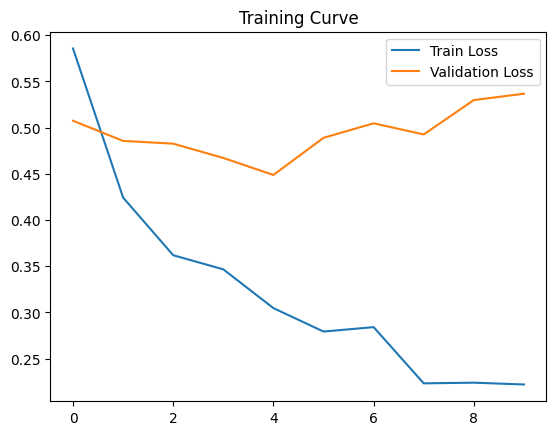

Validation ROC-AUC: 0.8766908212560387

Config: lr=0.0005, batch=32


c:\Users\VARADHARAJAN K\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\VARADHARAJAN K\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1 | Train Loss: 0.5228 | Val Loss: 0.5464
Epoch 2 | Train Loss: 0.3912 | Val Loss: 0.4981
Epoch 3 | Train Loss: 0.3251 | Val Loss: 0.4936
Epoch 4 | Train Loss: 0.2935 | Val Loss: 0.5166
Epoch 5 | Train Loss: 0.2443 | Val Loss: 0.5073
Epoch 6 | Train Loss: 0.2240 | Val Loss: 0.5116
Epoch 7 | Train Loss: 0.1819 | Val Loss: 0.5089
Epoch 8 | Train Loss: 0.1591 | Val Loss: 0.5121
Early stopping triggered at epoch 8


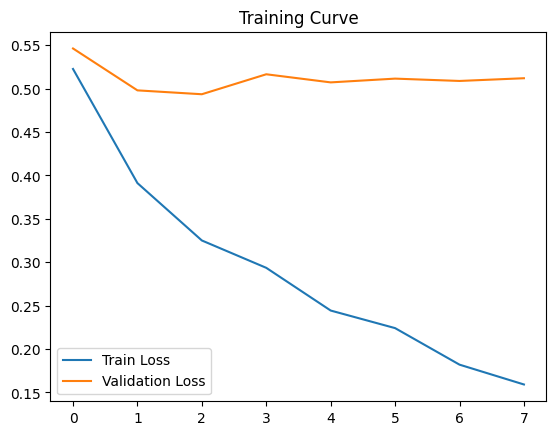

Validation ROC-AUC: 0.8624396135265701

Config: lr=0.0001, batch=16


c:\Users\VARADHARAJAN K\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\VARADHARAJAN K\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1 | Train Loss: 0.6067 | Val Loss: 0.5262
Epoch 2 | Train Loss: 0.5070 | Val Loss: 0.4859
Epoch 3 | Train Loss: 0.4611 | Val Loss: 0.4821
Epoch 4 | Train Loss: 0.4264 | Val Loss: 0.4741
Epoch 5 | Train Loss: 0.3920 | Val Loss: 0.4644
Epoch 6 | Train Loss: 0.3832 | Val Loss: 0.4549
Epoch 7 | Train Loss: 0.3775 | Val Loss: 0.4705
Epoch 8 | Train Loss: 0.3543 | Val Loss: 0.4700
Epoch 9 | Train Loss: 0.3748 | Val Loss: 0.4536
Epoch 10 | Train Loss: 0.3549 | Val Loss: 0.4554
Epoch 11 | Train Loss: 0.3117 | Val Loss: 0.4379
Epoch 12 | Train Loss: 0.3295 | Val Loss: 0.4405
Epoch 13 | Train Loss: 0.3221 | Val Loss: 0.4260
Epoch 14 | Train Loss: 0.2934 | Val Loss: 0.4361
Epoch 15 | Train Loss: 0.3032 | Val Loss: 0.4250
Epoch 16 | Train Loss: 0.2885 | Val Loss: 0.4551
Epoch 17 | Train Loss: 0.2847 | Val Loss: 0.4364
Epoch 18 | Train Loss: 0.2593 | Val Loss: 0.4486
Epoch 19 | Train Loss: 0.2591 | Val Loss: 0.4448
Epoch 20 | Train Loss: 0.2512 | Val Loss: 0.4460
Early stopping triggered at e

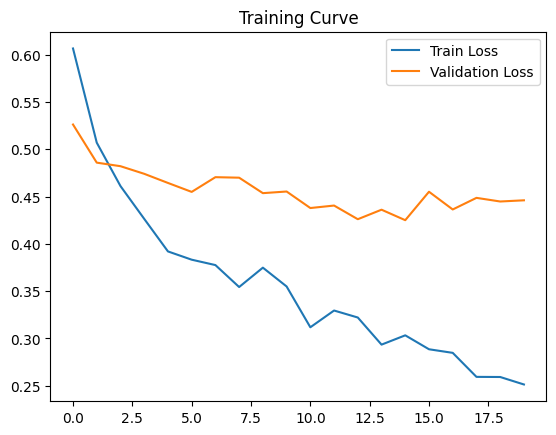

Validation ROC-AUC: 0.8865942028985507

Config: lr=0.0001, batch=32


c:\Users\VARADHARAJAN K\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\VARADHARAJAN K\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1 | Train Loss: 0.6230 | Val Loss: 0.6281
Epoch 2 | Train Loss: 0.5301 | Val Loss: 0.5401
Epoch 3 | Train Loss: 0.4967 | Val Loss: 0.5334
Epoch 4 | Train Loss: 0.4538 | Val Loss: 0.5262
Epoch 5 | Train Loss: 0.4394 | Val Loss: 0.5268
Epoch 6 | Train Loss: 0.4132 | Val Loss: 0.5157
Epoch 7 | Train Loss: 0.4140 | Val Loss: 0.5176
Epoch 8 | Train Loss: 0.3814 | Val Loss: 0.5197
Epoch 9 | Train Loss: 0.3614 | Val Loss: 0.5281
Epoch 10 | Train Loss: 0.3298 | Val Loss: 0.5215
Epoch 11 | Train Loss: 0.3263 | Val Loss: 0.5228
Early stopping triggered at epoch 11


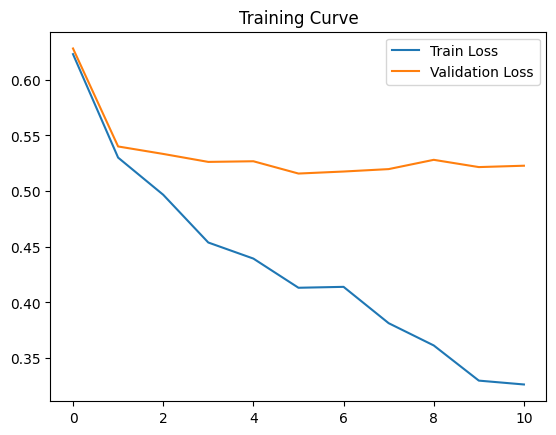

Validation ROC-AUC: 0.8381642512077295

Best config for MobileNetV2: {'lr': 0.0001, 'batch_size': 16}
Best validation AUC: 0.8866


In [24]:
#final comparison of all the models based on their test ROC-AUC scores, which are stored in a DataFrame and sorted in descending order to show the best performing model at the top
seq_results, seq_test = tune_sequence_models()
cnn_results, cnn_test = tune_cnn_models()
all_results = seq_results + cnn_results

In [25]:
#evaluate all models on the test set and store their AUC scores for comparison
comparison = []
for r in all_results:
    comparison.append({
        "Model": r["Model"],
        "Validation AUC": r["Best AUC"],
        "Best Hyperparameters": r["Best Config"]})
df = pd.DataFrame(comparison)
print("\nFINAL MODEL COMPARISON")
print(df.sort_values("Validation AUC", ascending=False))


FINAL MODEL COMPARISON
           Model  Validation AUC  \
4       ResNet18        0.962802   
2            GRU        0.950242   
3  AttentionLSTM        0.942874   
5    MobileNetV2        0.886594   
1           LSTM        0.625121   
0            RNN        0.615097   

                                Best Hyperparameters  
4                   {'lr': 0.0005, 'batch_size': 32}  
2  {'lr': 0.001, 'batch_size': 16, 'hidden_size':...  
3  {'lr': 0.001, 'batch_size': 16, 'hidden_size':...  
5                   {'lr': 0.0001, 'batch_size': 16}  
1  {'lr': 0.001, 'batch_size': 32, 'hidden_size':...  
0  {'lr': 0.0005, 'batch_size': 32, 'hidden_size'...  


In [26]:
#evaluate the best models on the test set and print their classification reports, confusion matrices and ROC curves
def evaluate_best_models(results, test_dataset, mode):
    test_loader = DataLoader(test_dataset, batch_size=32)
    for r in results:
        model = r["Model Object"]
        name = r["Model"]
        print(f"\nEvaluating {name} on test set")
        evaluate(model, test_loader, name)


Evaluating RNN on test set

RNN
              precision    recall  f1-score   support

           0       0.40      0.57      0.47        72
           1       0.64      0.47      0.54       116

    accuracy                           0.51       188
   macro avg       0.52      0.52      0.51       188
weighted avg       0.55      0.51      0.52       188



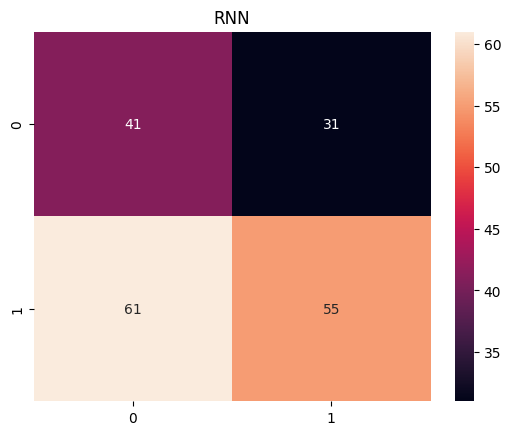

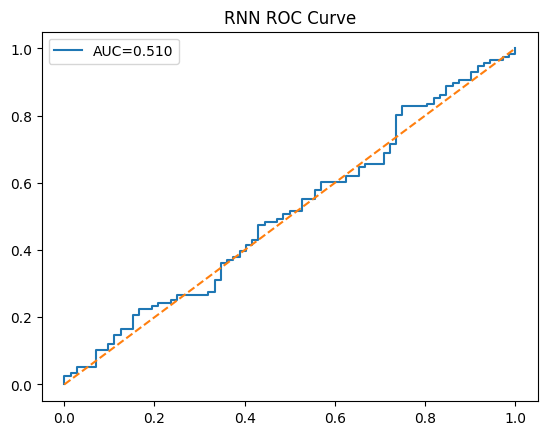


Evaluating LSTM on test set

LSTM
              precision    recall  f1-score   support

           0       0.43      0.75      0.55        72
           1       0.71      0.39      0.50       116

    accuracy                           0.53       188
   macro avg       0.57      0.57      0.53       188
weighted avg       0.61      0.53      0.52       188



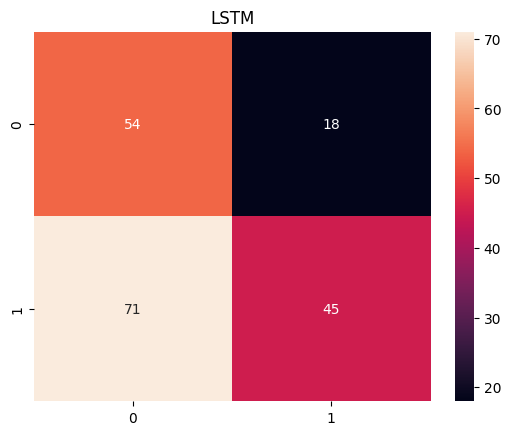

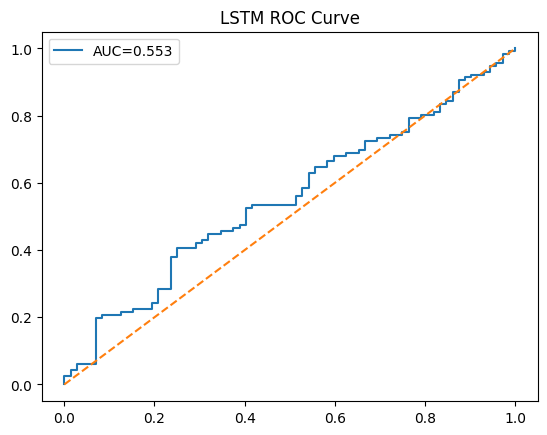


Evaluating GRU on test set

GRU
              precision    recall  f1-score   support

           0       0.88      0.88      0.88        72
           1       0.92      0.92      0.92       116

    accuracy                           0.90       188
   macro avg       0.90      0.90      0.90       188
weighted avg       0.90      0.90      0.90       188



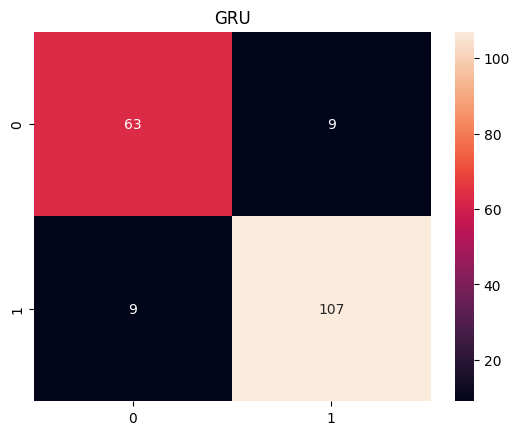

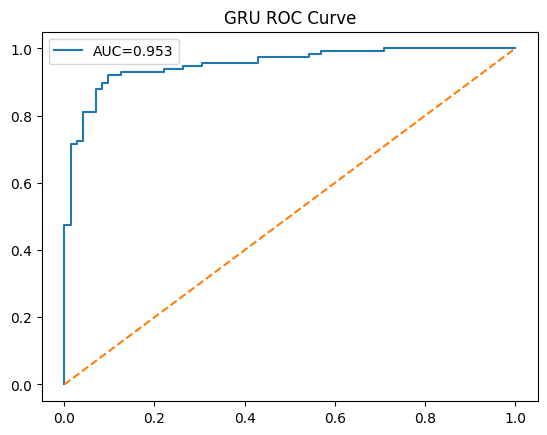


Evaluating AttentionLSTM on test set

AttentionLSTM
              precision    recall  f1-score   support

           0       0.76      0.90      0.82        72
           1       0.93      0.82      0.87       116

    accuracy                           0.85       188
   macro avg       0.84      0.86      0.85       188
weighted avg       0.86      0.85      0.85       188



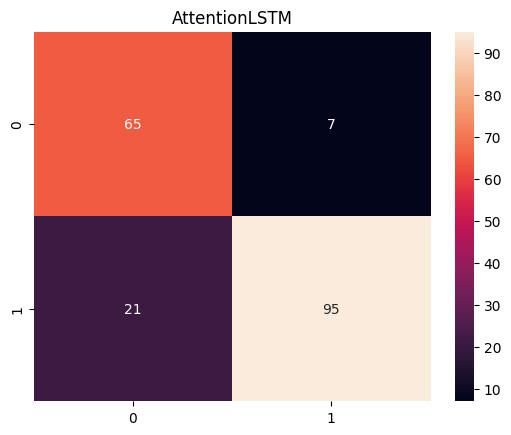

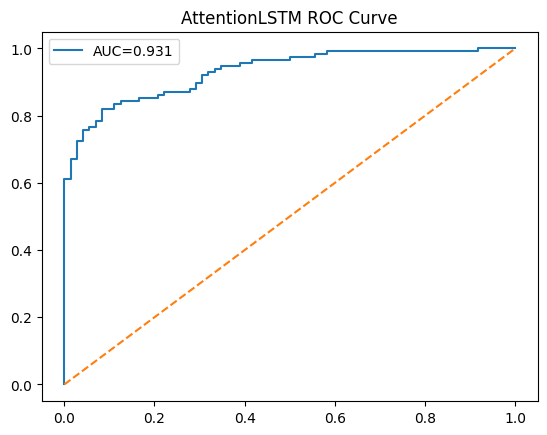


Evaluating ResNet18 on test set

ResNet18
              precision    recall  f1-score   support

           0       0.92      0.81      0.86        72
           1       0.89      0.96      0.92       116

    accuracy                           0.90       188
   macro avg       0.90      0.88      0.89       188
weighted avg       0.90      0.90      0.90       188



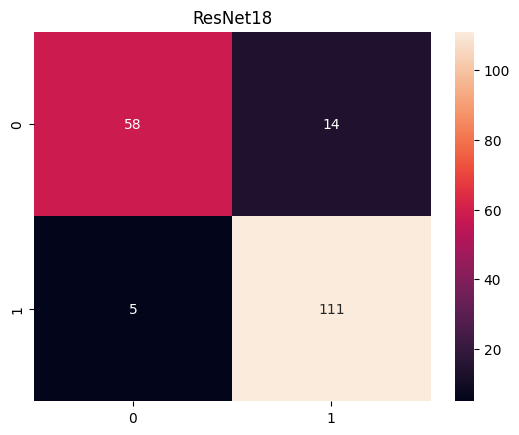

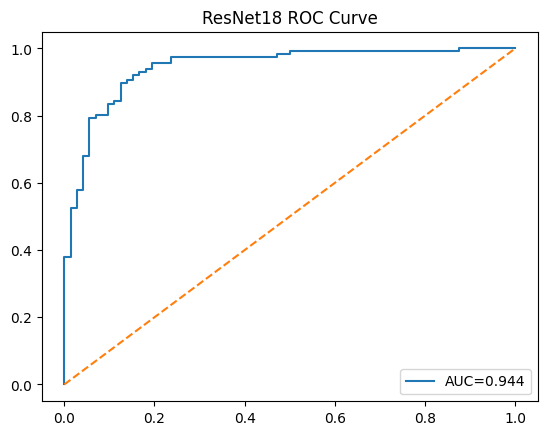


Evaluating MobileNetV2 on test set

MobileNetV2
              precision    recall  f1-score   support

           0       0.74      0.78      0.76        72
           1       0.86      0.83      0.84       116

    accuracy                           0.81       188
   macro avg       0.80      0.80      0.80       188
weighted avg       0.81      0.81      0.81       188



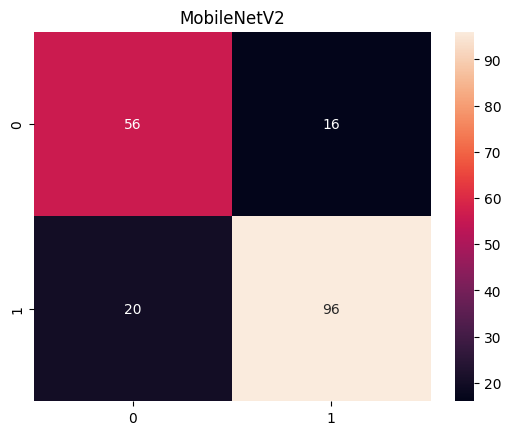

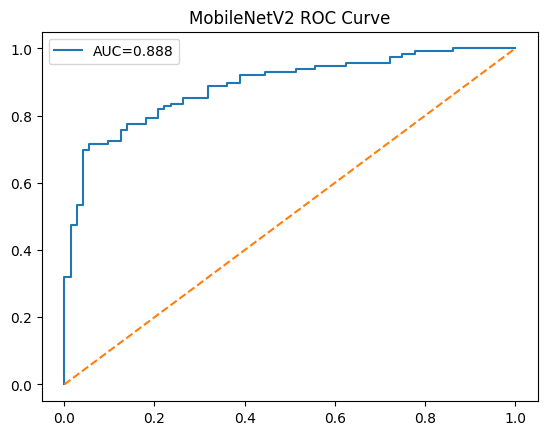

In [27]:
#evaluate the best models on the test set and print their classification reports, confusion matrices and ROC curves
evaluate_best_models(seq_results, seq_test, "mfcc")
evaluate_best_models(cnn_results, cnn_test, "mel")

In [28]:
#function defined for plotting the gradient flow of the model during training, which can help in diagnosing issues like vanishing or exploding gradients by visualizing the average gradient magnitude for each layer in the model
def plot_gradient_flow(model):
    grads = []
    for name, param in model.named_parameters():
        if param.requires_grad and param.grad is not None:
            grads.append(param.grad.abs().mean().item())
    plt.plot(grads)
    plt.title("Gradient Flow")
    plt.xlabel("Layer Index")
    plt.ylabel("Average Gradient")
    plt.show()

Gradient flow for: RNN


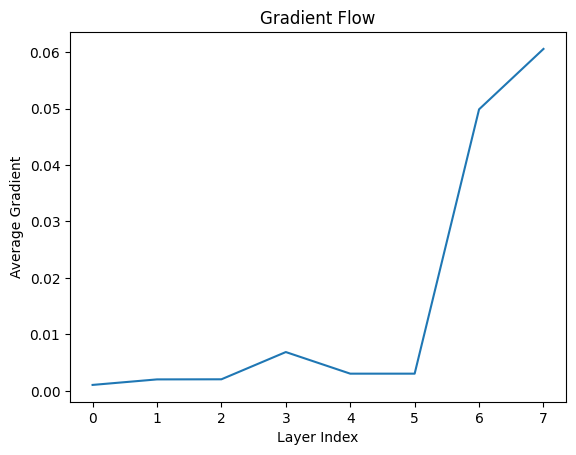

Gradient flow for: LSTM


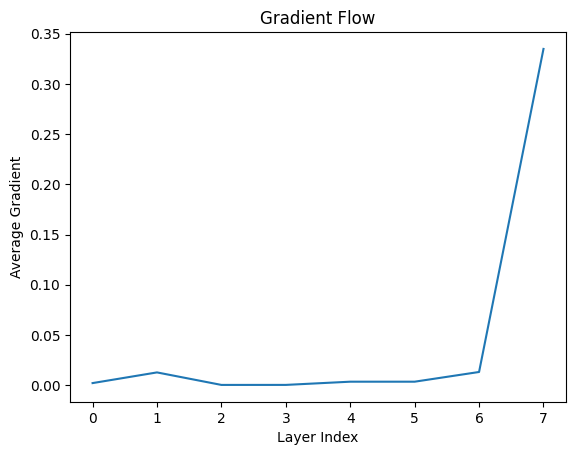

Gradient flow for: GRU


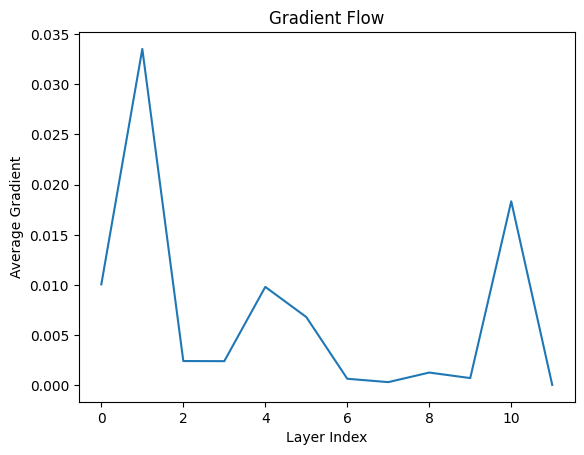

Gradient flow for: AttentionLSTM


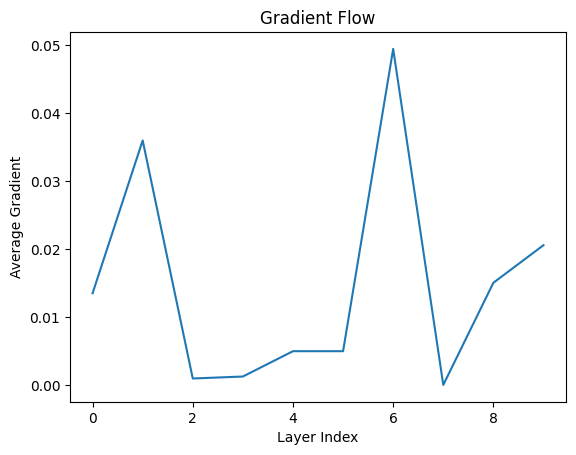

In [29]:
#plot the gradient flow for the best sequence models
for r in seq_results:
    model = r["Model Object"]
    name = r["Model"]
    print("Gradient flow for:", name)
    plot_gradient_flow(model)